# H1: Descriptive Norm Effect

**Hypothesis**: Higher perceived prevalence of peer cheating will be associated with greater individual willingness to engage in unauthorized assistance, consistent with focus theory's account of descriptive norms as a primary behavioral driver (Cialdini et al., 1991).

**Relevant Survey Items:**
| Variable | Column | Question |
|---|---|---|
| `q2_pct_cheated` | Question 2_1 | Estimated % of peers who have cheated |
| `q9_know_ai_hw` | Question 9 | Know someone: AI for prohibited homework |
| `q10_know_ai_adv` | Question 10 | Know someone: AI for interview answers in advance |
| `q11_know_search_live` | Question 11 | Know someone: search/peer help live during interview |
| `q12_know_ai_live` | Question 12 | Know someone: AI live during virtual interview |
| `q13a_willingness_high` | Question 13a | Willingness under HIGH peer cheating condition |
| `q14a_willingness_no` | Question 14a | Willingness under NO peer cheating condition |
| `q17_industry` | Question 17 | Industry (for DeGroot block structure) |

**Q9–Q12 coding note**: These items are attention-check coded. Each respondent is assigned a HAVE_SYMBOL (an uppercase letter) and a HAVE_NOT_SYMBOL (a colour). Correct responses depend on which symbol the respondent was assigned — the notebook decodes these automatically.

**Fixed agent data (from paper):**
- Q2 mean: 12.7%, clustered at 5/10/15%
- Q9: 3/150 agents know someone (AI homework); Q10–Q12: 0/150
- Q13a: 0% willing (140 Somewhat Unlikely, 10 Extremely Unlikely)
- Q14a: 100% Extremely Unlikely

---

## 1. Setup and Data Loading

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi'       : 150,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'font.family'      : 'sans-serif',
    'axes.titlesize'   : 13,
    'axes.labelsize'   : 11,
})
HUMAN_COLOR   = '#2563EB'
AGENT_COLOR   = '#DC2626'
NEUTRAL_COLOR = '#6B7280'
BAND_COLORS   = ['#BFD7FF', '#6AA3F8', '#2563EB', '#0D3A8A']  # light→dark blue per experience band
N_AGENTS = 150
print('Libraries loaded.')

Libraries loaded.


In [48]:
# ── Load data ──────────────────────────────────────────────────────────────────
# Row 0  = question text (long-form)
# Row 1  = Qualtrics import IDs  → skip
# Rows 2+ = actual responses
#raw = pd.read_excel('New Microsoft Excel Worksheet.xlsx', header=0)
raw = pd.read_excel("cleaned.xlsx", header=0)

# Human responses start at row index 2 (0-indexed in the raw frame)
df = raw.iloc[1:].copy().reset_index(drop=True)

# Rename columns to short, meaningful labels using the survey map below
col_map = {
    'Consent Page'            : 'consent',
    'Question 1_1'            : 'q1_smartphone',
    'Question 1_2'            : 'q1_music',
    'Question 1_3'            : 'q1_coffee',
    'Question 1_4'            : 'q1_skydive',
    'Question 1_5'            : 'q1_helicopter',
    'Question 1_6'            : 'q1_pay_interview',
    'Question 1_7'            : 'q1_gym',
    'Question 1_8'            : 'q1_cheat_partner',
    'Question 1_9'            : 'q1_exam_cheat',
    'Question 1_10'           : 'q1_ai_interview_answers',
    'Question 1_11'           : 'q1_ai_practice',
    'Question 1_12'           : 'q1_essay_ghost',
    'Question 1_13'           : 'q1_hidden_assist',
    'Question 1_14'           : 'q1_perform_music',
    'Question 2_1'            : 'q2_pct_cheated',
    'Question 3_1'            : 'q3_ai_during',
    'Question 3_2'            : 'q3_search_engine',
    'Question 3_3'            : 'q3_questions_beforehand',
    'Question 3_4'            : 'q3_live_assist',
    'Question 3_5'            : 'q3_handwritten_notes',
    'Question 3_6'            : 'q3_ai_notes',
    'Question 4'              : 'q4_attention_color',
    'Question 5a_1'           : 'q5a_desperation',
    'Question 5a_2'           : 'q5a_competition',
    'Question 5a_3'           : 'q5a_confidence',
    'Question 5a_4'           : 'q5a_unfair_process',
    'Question 5a_5'           : 'q5a_online_risk',
    'Question 5a_6'           : 'q5a_cultural_norms',
    'Question 5a_7'           : 'q5a_lack_guidance',
    'Question 5a_8'           : 'q5a_bandwagon',
    'Question 6'              : 'q6_open_why_cheat',
    'Question 7'              : 'q7_attention_chicago_il',
    'Question 8'              : 'q8_attention_chicago_ny',
    'Question 9'              : 'q9_know_ai_hw',
    'Question 10'             : 'q10_know_ai_interview_adv',
    'Question 11'             : 'q11_know_search_live',
    'Question 12'             : 'q12_know_ai_live',
    'Q37'                     : 'code_id_raw',
    'Question 13a'            : 'q13a_willingness_high_peer',
    'Question 13b'            : 'q13b_acceptable_high_peer',
    'Question 14a'            : 'q14a_willingness_no_peer',
    'Question 14b'            : 'q14b_acceptable_no_peer',
    'Question 15'             : 'q15_year',
    'Question 16'             : 'q16_field',
    'Question 16_21_TEXT'     : 'q16_field_other',
    'Question 17'             : 'q17_industry',
    'Question 17_19_TEXT'     : 'q17_industry_other',
    'Question 18'             : 'q18_employment',
    'Question 19'             : 'q19_num_interviews',
    'Question 20'             : 'q20_interview_format',
    'Feedback Question'       : 'feedback',
    'Raffle Question'         : 'raffle',
    'Branching Question'      : 'branching',
    'Optional Question 1'     : 'q21_fairness',
    'Optional Question 2'     : 'q22_report_peer',
    'Optional Question 3'     : 'q23_detect_confidence',
    'Optional Question 4'     : 'q24_enforce_confidence',
    'Optional Question 5'     : 'q25_consequence',
    'Optional Question 6'     : 'q26_ai_skill_confidence',
    'HAVE_SYMBOL'             : 'have_symbol',
    'HAVE_NOT_SYMBOL'         : 'have_not_symbol',
    'CODE_ID'                 : 'code_id',
}
df.rename(columns=col_map, inplace=True)
df.head(200)

,UserLanguage,consent,q1_smartphone,q1_music,q1_coffee,q1_skydive,q1_helicopter,q1_pay_interview,q1_gym,q1_cheat_partner,...,q25_consequence,q26_ai_skill_confidence,have_symbol,have_not_symbol,code_id,Q_AmbiguousTextPresent,Q_AmbiguousTextQuestions,Q_StraightliningCount,Q_StraightliningPercentage,Q_StraightliningQuestions
0,EN,I agree to participate in this research study.,Very Common,Very Common,Very Common,Uncommon,Very Rare,Very Rare,NaN,Rare,...,NaN,NaN,ODD NUMBER,UPPERCASE LETTER,4,0,NaN,0,0,NaN
1,EN,I agree to participate in this research study.,Very Common,NaN,Very Common,NaN,Very Rare,Very Rare,Common,Uncommon,...,NaN,NaN,UPPERCASE LETTER,COLOR,1,0,NaN,0,0,NaN
2,EN,I agree to participate in this research study.,NaN,Very Common,Very Common,Rare,Very Rare,NaN,NaN,Uncommon,...,Automatic disqualification from the current ap...,Not confident at all,UPPERCASE LETTER,COLOR,1,0,NaN,1,0.333333,QID11
3,EN,I agree to participate in this research study.,NaN,NaN,Very Common,Uncommon,Very Rare,Rare,Common,Rare,...,Permanent ban from applying to the company.,Slightly confident,UPPERCASE LETTER,COLOR,1,0,NaN,0,0,NaN
4,EN,I agree to participate in this research study.,Very Common,Common,Very Common,Very Rare,Very Rare,NaN,Common,Very Rare,...,NaN,NaN,LOWERCASE LETTER,EVEN NUMBER,5,0,NaN,1,0.333333,QID11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,EN,I agree to participate in this research study.,NaN,NaN,Common,Very Rare,Very Rare,NaN,Very Rare,Uncommon,...,NaN,NaN,UPPERCASE LETTER,COLOR,1,0,NaN,0,0,NaN
196,EN,I agree to participate in this research study.,NaN,Very Common,Very Common,NaN,Very Rare,NaN,Common,Rare,...,NaN,NaN,ODD NUMBER,UPPERCASE LETTER,4,0,NaN,0,0,NaN
197,EN,I agree to participate in this research study.,Very Common,Very Common,Very Common,NaN,Very Rare,Very Rare,Common,Rare,...,NaN,NaN,LOWERCASE LETTER,EVEN NUMBER,5,0,NaN,0,0,NaN
198,EN,I agree to participate in this research study.,NaN,NaN,Common,Rare,Very Rare,NaN,NaN,Very Rare,...,Permanent ban from applying to the company.,Not confident at all,UPPERCASE LETTER,COLOR,1,0,NaN,0,0,NaN


In [49]:
# ── Scale maps ─────────────────────────────────────────────────────────────────
willing_map = {
    'Extremely unlikely'         : 1,
    'Somewhat unlikely'          : 2,
    'Neither likely nor unlikely': 3,
    'Somewhat likely'            : 4,
    'Extremely likely'           : 5,
    'Extremely Likely'           : 5,
}
df['q13a_n']  = df['q13a_willingness_high_peer'].map(willing_map)
df['q14a_n']  = df['q14a_willingness_no_peer'].map(willing_map)
df['q2_n']    = pd.to_numeric(df['q2_pct_cheated'], errors='coerce')
df['shift']   = df['q13a_n'] - df['q14a_n']

def matches_symbol_type(answer, symbol):
    """
    Returns True if `answer` fits the same category as `symbol`.
    e.g. if symbol is 'A' (uppercase letter), any uppercase letter in answer = True.
    """
    a = str(answer).strip()
    s = str(symbol).strip()

    COLORS = {'red','blue','green','yellow','orange','purple','pink',
              'black','white','brown','grey','gray'}
    #print(f"Matching answer '{a}' to symbol '{s}'")
    if s == 'UPPERCASE LETTER':
        return a.upper() == a and a.isalpha() and len(a) == 1
    if s == 'LOWERCASE LETTER':
        return a.lower() == a and a.isalpha() and len(a) == 1
    if s == 'ODD NUMBER':
        return a.lstrip('-').isdigit() and int(a) % 2 == 1
    if s == 'EVEN NUMBER':
        return a.lstrip('-').isdigit() and int(a) % 2 == 0
    if s == 'COLOR':
        return a.lower() in COLORS
    # fallback: exact match
    return a.lower() == s.lower()

# ── Q9–Q12 attention-check decoding ──────────────────────────────────────────
# Correct = answer fits the category of have_symbol (not have_not_symbol)
df['q9_know']  = df.apply(lambda r: matches_symbol_type(r['q9_know_ai_hw'],          r['have_symbol']), axis=1)
df['q10_know'] = df.apply(lambda r: matches_symbol_type(r['q10_know_ai_interview_adv'], r['have_symbol']), axis=1)
df['q11_know'] = df.apply(lambda r: matches_symbol_type(r['q11_know_search_live'],    r['have_symbol']), axis=1)
df['q12_know'] = df.apply(lambda r: matches_symbol_type(r['q12_know_ai_live'],        r['have_symbol']), axis=1)
#df.head(200)


In [50]:

# Any-know flag: respondent knows at least one cheater across Q9–Q12
df['any_know'] = df[['q9_know','q10_know','q11_know','q12_know']].any(axis=1)

# Willing flag: Somewhat or Extremely Likely on Q13a
df['willing_high_flag'] = df['q13a_willingness_high_peer'].isin(
    ['Somewhat likely','Extremely Likely','Extremely likely'])
df['unwilling_no_flag'] = df['q14a_willingness_no_peer'].isin(
    ['Extremely unlikely','Somewhat unlikely'])

# Industry simplification
industry_remap = {
    'Technology: Software / SaaS / AI'               : 'Tech',
    'Finance: Investment Banking'                     : 'Finance',
    'Finance: Private Equity / Hedge Fund'            : 'Finance',
    'Finance: Corporate Finance / Accounting'         : 'Finance',
    'Finance: FinTech'                                : 'Finance',
    'Consulting'                                      : 'Consulting',
    'Healthcare: Biotech / Pharma / Research'         : 'Healthcare',
    'Healthcare: Clinical / Hospital Administration'  : 'Healthcare',
    'Education'                                       : 'Education',
    'Law'                                             : 'Law',
    'Marketing / Advertising / PR'                    : 'Marketing',
    'Engineering (non-software)'                      : 'Engineering',
    'Government / Public Policy'                      : 'Gov/Policy',
    'Non-profit / Social Impact'                      : 'Non-profit',
    'Media / Entertainment / Sports'                  : 'Media',
}
df['industry'] = df['q17_industry'].map(industry_remap).fillna(
    df['q17_industry'].str.split(':').str[0].str.strip())

print(f'Dataset: {len(df)} human respondents')
print(f'Q9-Q12 know-someone rates:')
for col, lbl in [('q9_know','Q9 AI homework'),('q10_know','Q10 AI adv answers'),
                  ('q11_know','Q11 search/peer live'),('q12_know','Q12 AI live')]:
    n   = df[col].sum()
    pct = n / len(df) * 100
    print(f'  {lbl:<22}: n={n} ({pct:.1f}%)')

print(f'  Any know (≥1 behavior): n={df["any_know"].sum()} ({df["any_know"].mean()*100:.1f}%)')

Dataset: 249 human respondents
Q9-Q12 know-someone rates:
  Q9 AI homework        : n=222 (89.2%)
  Q10 AI adv answers    : n=93 (37.3%)
  Q11 search/peer live  : n=67 (26.9%)
  Q12 AI live           : n=65 (26.1%)
  Any know (≥1 behavior): n=227 (91.2%)


---
## 2. Q2: Peer Cheating Estimate Distribution

> *"Human respondents estimated, on average, that [X]% of job-seekers they know have cheated... median of [X]%. This stands in sharp contrast to the agent cohort, whose estimates clustered tightly around 12.7%."*

In [51]:
# ── Fill-in computations ───────────────────────────────────────────────────────
q2_valid = df['q2_n'].dropna()
print('── Q2: Peer Cheating Estimate (Human) ──')
print(f'  n          : {len(q2_valid)}')
print(f'  Mean       : {q2_valid.mean():.1f}%')
print(f'  Median     : {q2_valid.median():.1f}%')
print(f'  SD         : {q2_valid.std():.1f}%')
print(f'  Min / Max  : {q2_valid.min():.0f}% / {q2_valid.max():.0f}%')
print(f'  Skewness   : {q2_valid.skew():.2f}')

# Agent comparison
agent_q2_mean   = 12.7
agent_q2_values = [5]*50 + [10]*50 + [15]*50  # approximate from paper
print(f'\n── Q2: Agent (fixed from paper) ──')
print(f'  Mean: {agent_q2_mean}%  clustered at 5/10/15%')

# Mann-Whitney test
if len(q2_valid) >= 2:
    stat, pval = stats.mannwhitneyu(q2_valid, agent_q2_values, alternative='greater')
    print(f'\nMann-Whitney U (human > agent): U={stat:.1f}, p={pval:.4f}')

print('\n── [X] FILL-IN VALUES FOR LATEX ──')
print(f'  Mean  : {q2_valid.mean():.1f}%')
print(f'  Median: {q2_valid.median():.1f}%')
# "if a candidate believes that [X]% of their peers have cheated"
print(f'  Modal belief [X]%: {q2_valid.mode().iloc[0]:.0f}%' if len(q2_valid) > 0 else '  [no data]')

── Q2: Peer Cheating Estimate (Human) ──
  n          : 249
  Mean       : 36.7%
  Median     : 33.0%
  SD         : 21.8%
  Min / Max  : 0% / 95%
  Skewness   : 0.54

── Q2: Agent (fixed from paper) ──
  Mean: 12.7%  clustered at 5/10/15%

Mann-Whitney U (human > agent): U=33725.0, p=0.0000

── [X] FILL-IN VALUES FOR LATEX ──
  Mean  : 36.7%
  Median: 33.0%
  Modal belief [X]%: 20%


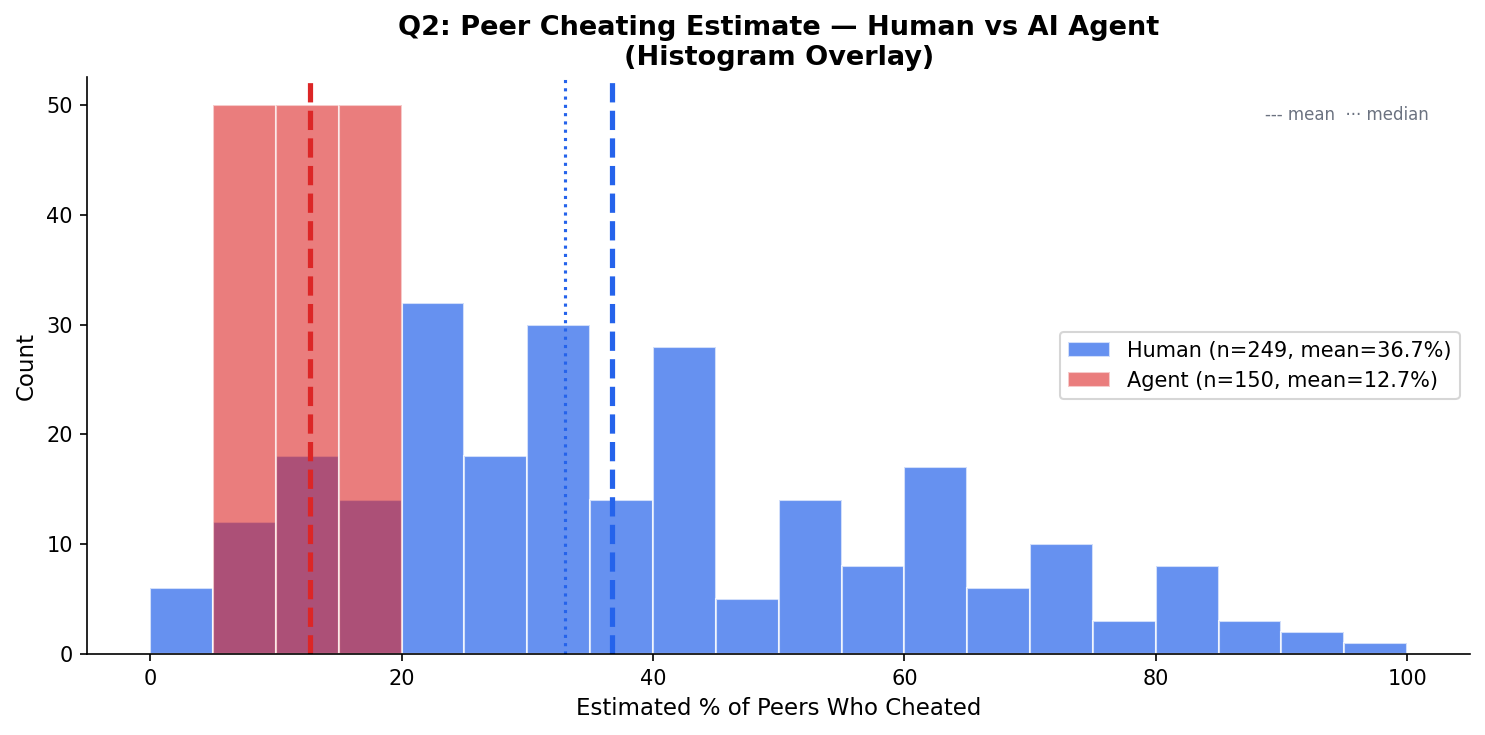

Saved: fig_h1_q2_distribution_histogram.png


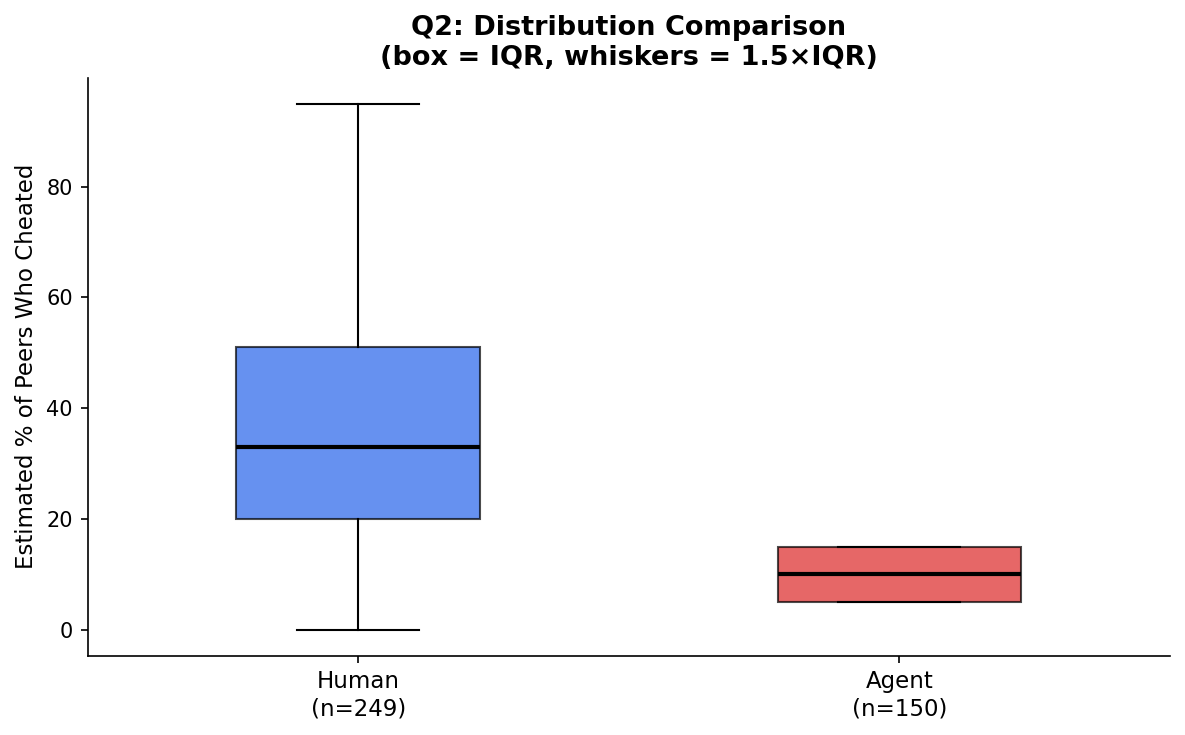

Saved: fig_h1_q2_distribution_boxplot.png


In [52]:
# ── Figure 1a: Q2 distribution — histogram overlay ────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
bins = np.arange(0, 105, 5)
if len(q2_valid) > 0:
    ax.hist(q2_valid, bins=bins, color=HUMAN_COLOR, alpha=0.7,
            label=f'Human (n={len(q2_valid)}, mean={q2_valid.mean():.1f}%)',
            edgecolor='white', density=False)
ax.hist(agent_q2_values, bins=bins, color=AGENT_COLOR, alpha=0.6,
        label=f'Agent (n={N_AGENTS}, mean={agent_q2_mean}%)',
        edgecolor='white', density=False)
if len(q2_valid) > 0:
    ax.axvline(q2_valid.mean(),   color=HUMAN_COLOR, linewidth=2.5, linestyle='--')
    ax.axvline(q2_valid.median(), color=HUMAN_COLOR, linewidth=1.5, linestyle=':')
ax.axvline(agent_q2_mean, color=AGENT_COLOR, linewidth=2.5, linestyle='--')
ax.set_xlabel('Estimated % of Peers Who Cheated')
ax.set_ylabel('Count')
ax.set_title('Q2: Peer Cheating Estimate — Human vs AI Agent\n(Histogram Overlay)', fontweight='bold')
ax.legend(fontsize=10)
ax.text(0.97, 0.95, '--- mean  ··· median', transform=ax.transAxes,
        fontsize=8, ha='right', va='top', color=NEUTRAL_COLOR)
plt.tight_layout()
plt.savefig('fig_h1_q2_distribution_histogram.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: fig_h1_q2_distribution_histogram.png')

# ── Figure 1b: Q2 distribution — box comparison ────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
data_box = []
labels_box = []
if len(q2_valid) > 0:
    data_box.append(q2_valid.values)
    labels_box.append(f'Human\n(n={len(q2_valid)})')
data_box.append(agent_q2_values)
labels_box.append(f'Agent\n(n={N_AGENTS})')
bp = ax.boxplot(data_box, patch_artist=True, widths=0.45,
                 medianprops=dict(color='black', linewidth=2))
colors_box = [HUMAN_COLOR, AGENT_COLOR][:len(data_box)]
for patch, col in zip(bp['boxes'], colors_box):
    patch.set_facecolor(col)
    patch.set_alpha(0.7)
ax.set_xticklabels(labels_box, fontsize=11)
ax.set_ylabel('Estimated % of Peers Who Cheated')
ax.set_title('Q2: Distribution Comparison\n(box = IQR, whiskers = 1.5×IQR)', fontweight='bold')
plt.tight_layout()
plt.savefig('fig_h1_q2_distribution_boxplot.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: fig_h1_q2_distribution_boxplot.png')


In [ ]:
df = pd.read_excel('cleaned.xlsx', skiprows=1)
cols = list(df.columns)
q2_col = [c for c in cols if 'percentage of students' in str(c)][0]
q2 = pd.to_numeric(df[q2_col], errors='coerce').dropna()

mean_val = q2.mean()
median_val = q2.median()

fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(q2, bins=range(0, 101, 5), color='steelblue', edgecolor='white', linewidth=0.6, zorder=2)

ax.axvline(mean_val, color='firebrick', linestyle='--', linewidth=1.5, label=f'Mean = {mean_val:.1f}%', zorder=3)
ax.axvline(median_val, color='darkorange', linestyle=':', linewidth=1.5, label=f'Median = {median_val:.0f}%', zorder=3)

ax.set_xlabel('Estimated % of job-seekers who have cheated on an interview', fontsize=12)
ax.set_ylabel('Number of respondents', fontsize=12)
ax.set_title('Distribution of Beliefs About Peer Interview Cheating Prevalence\n(Question 2, N = 249)', fontsize=13)

ax.xaxis.set_major_locator(mticker.MultipleLocator(10))
ax.xaxis.set_minor_locator(mticker.MultipleLocator(5))
ax.set_xlim(0, 100)
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))

ax.legend(fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.4, zorder=1)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('fig_q2_histogram.png', dpi=150, bbox_inches='tight')
plt.close()
print("Saved fig_q2_histogram.png")


---
## 3. Q9–Q12: Disclosure Items (Know Someone Who Cheated)

> *"Among human respondents, [X]% reported knowing someone who had used AI to complete a homework assignment (Q9), [X]% AI interview answers in advance (Q10), [X]% search/peer live (Q11), [X]% AI live (Q12)."*

In [53]:
# ── Fill-in computations ───────────────────────────────────────────────────────
know_cols   = ['q9_know','q10_know','q11_know','q12_know']
know_labels = [
    'Q9: AI for prohibited\nhomework',
    'Q10: AI for interview\nanswers in advance',
    'Q11: Search/peer help\nlive during interview',
    'Q12: AI live during\nvirtual interview',
]
know_labels_short = ['Q9: AI\nhomework','Q10: AI\nadv. answers',
                     'Q11: Search/peer\nlive','Q12: AI\nlive']

# Agent data (fixed)
agent_know = {'q9_know': 3/150*100, 'q10_know': 0, 'q11_know': 0, 'q12_know': 0}

print('── Q9–Q12: Know-Someone Rates ──')
print(f'  {"Item":<35} {"Human n":>9} {"Human %":>9} {"Agent %":>9}')
print('  ' + '-'*62)
for col, lbl in zip(know_cols, know_labels):
    n   = df[col].sum()
    pct = n / len(df) * 100 if len(df) > 0 else np.nan
    apct = agent_know[col]
    print(f'  {lbl.replace(chr(10)," "):<35} {n:>9} {pct:>8.1f}% {apct:>8.1f}%')

print(f'\n  Any know (≥1 behavior): n={df["any_know"].sum()} ({df["any_know"].mean()*100:.1f}%)')

print('\n── [X] FILL-IN VALUES FOR LATEX ──')
for col, lbl in zip(know_cols, ['Q9','Q10','Q11','Q12']):
    pct = df[col].mean() * 100 if len(df) > 0 else np.nan
    print(f'  {lbl}: {pct:.1f}%')

── Q9–Q12: Know-Someone Rates ──
  Item                                  Human n   Human %   Agent %
  --------------------------------------------------------------
  Q9: AI for prohibited homework            222     89.2%      2.0%
  Q10: AI for interview answers in advance        93     37.3%      0.0%
  Q11: Search/peer help live during interview        67     26.9%      0.0%
  Q12: AI live during virtual interview        65     26.1%      0.0%

  Any know (≥1 behavior): n=227 (91.2%)

── [X] FILL-IN VALUES FOR LATEX ──
  Q9: 89.2%
  Q10: 37.3%
  Q11: 26.9%
  Q12: 26.1%


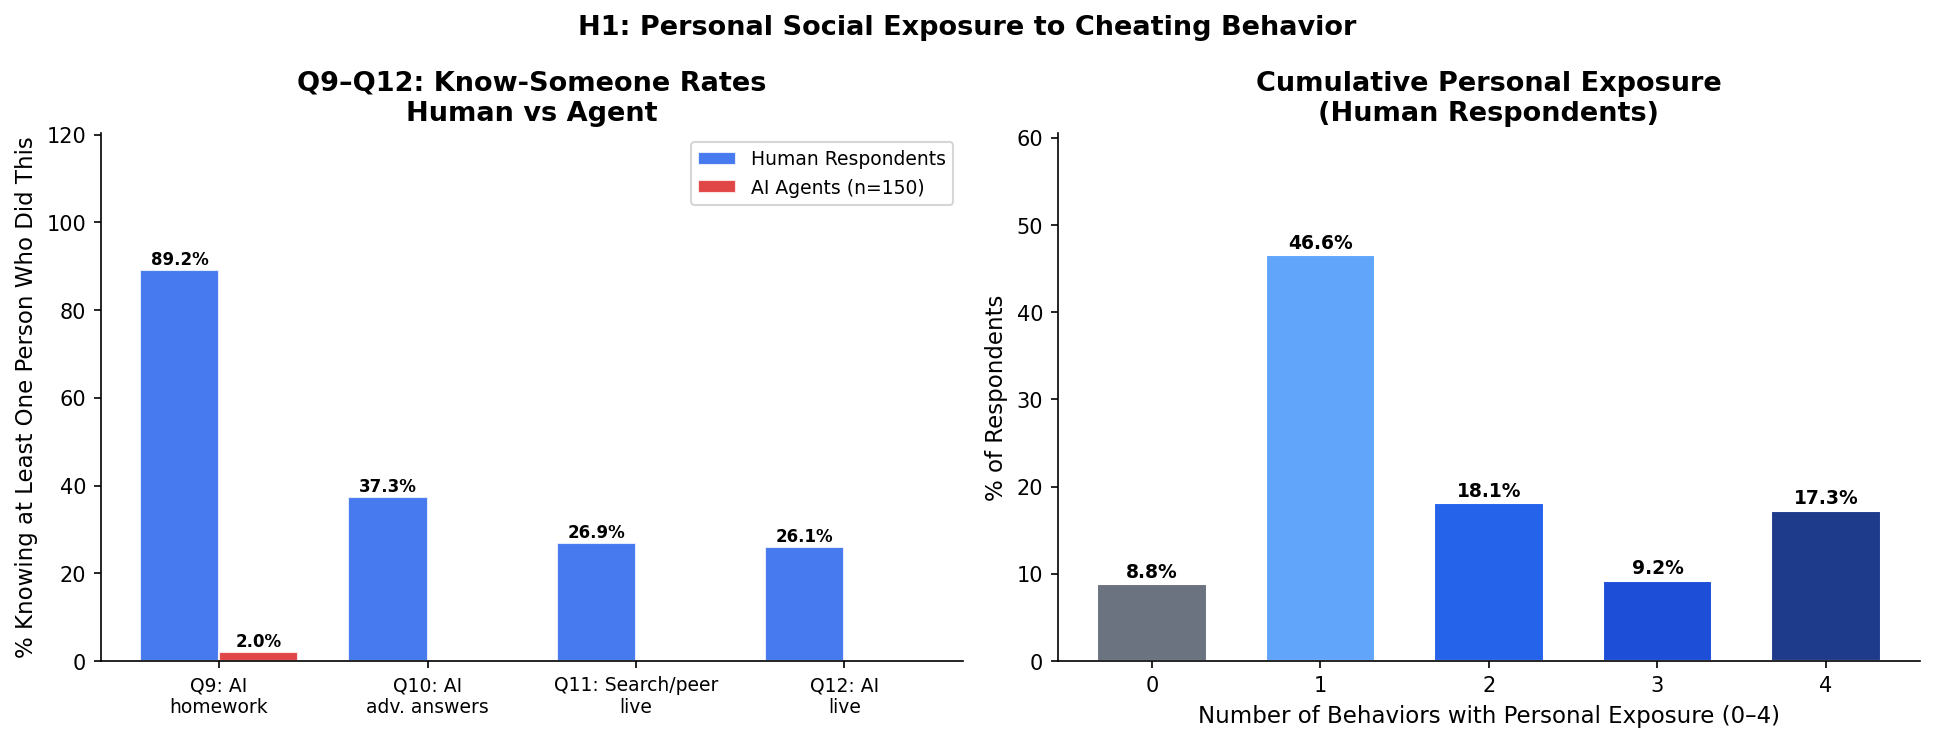

Saved: fig_h1_disclosure_rates.png


In [54]:
# ── Figure 2: Know-someone rates — Human vs Agent ─────────────────────────────
human_pcts = [df[c].mean()*100 for c in know_cols]
agent_pcts = [agent_know[c] for c in know_cols]

x = np.arange(len(know_cols))
width = 0.38

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: grouped bar
ax = axes[0]
bars_h = ax.bar(x - width/2, human_pcts, width, label='Human Respondents',
                color=HUMAN_COLOR, alpha=0.85, edgecolor='white')
bars_a = ax.bar(x + width/2, agent_pcts, width, label='AI Agents (n=150)',
                color=AGENT_COLOR, alpha=0.85, edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(know_labels_short, fontsize=9)
ax.set_ylabel('% Knowing at Least One Person Who Did This')
ax.set_title('Q9–Q12: Know-Someone Rates\nHuman vs Agent', fontweight='bold')
max_v = max(max(human_pcts), max(agent_pcts)) if max(human_pcts) > 0 else 10
ax.set_ylim(0, max(max_v * 1.35, 10))
ax.legend(fontsize=9)
for bar, val in list(zip(bars_h, human_pcts)) + list(zip(bars_a, agent_pcts)):
    if val > 0:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                f'{val:.1f}%', ha='center', va='bottom', fontsize=8, fontweight='bold')

# Right: cumulative exposure — how many behaviors does each respondent know someone for?
ax2 = axes[1]
df['n_know'] = df[know_cols].sum(axis=1)
know_counts = df['n_know'].value_counts().sort_index().reindex(range(5), fill_value=0)
know_pcts   = (know_counts / len(df) * 100)
bars2 = ax2.bar(know_counts.index, know_pcts.values,
                color=[NEUTRAL_COLOR, '#60A5FA', '#2563EB', '#1D4ED8', '#1E3A8A'],
                edgecolor='white', width=0.65)
ax2.set_xlabel('Number of Behaviors with Personal Exposure (0–4)')
ax2.set_ylabel('% of Respondents')
ax2.set_title('Cumulative Personal Exposure\n(Human Respondents)', fontweight='bold')
ax2.set_xticks(range(5))
for bar, val in zip(bars2, know_pcts.values):
    if val > 0:
        ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                 f'{val:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
max_v2 = max(know_pcts.values)
ax2.set_ylim(0, max(max_v2 * 1.3, 10))

plt.suptitle('H1: Personal Social Exposure to Cheating Behavior', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_h1_disclosure_rates.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: fig_h1_disclosure_rates.png')

---
## 4. Know-Someone × Willingness Cross-Tab

> *"Respondents who reported knowing at least one person who had engaged in any of the four behaviors were [X] times more likely to report being 'Somewhat Likely' or 'Extremely Likely' to cheat."*

In [55]:
# ── Fill-in computations ───────────────────────────────────────────────────────
know_group    = df[df['any_know'] == True]
no_know_group = df[df['any_know'] == False]

know_willing_rate    = know_group['willing_high_flag'].mean()
no_know_willing_rate = no_know_group['willing_high_flag'].mean()
ratio = know_willing_rate / no_know_willing_rate \
        if no_know_willing_rate > 0 else np.nan

print('── Know-Someone × Willingness (Q13a) ──')
print(f'  Know ≥1 cheater      : n={len(know_group)}, willing rate={know_willing_rate*100:.1f}%')
print(f'  Know no cheaters     : n={len(no_know_group)}, willing rate={no_know_willing_rate*100:.1f}%')
print(f'  Likelihood ratio     : {ratio:.2f}x' if not np.isnan(ratio)
      else '  Ratio: [insufficient data in both groups]')

# Mean willingness score by exposure level
will_by_exposure = df.groupby('n_know')['q13a_n'].agg(['mean','sem','count'])
print('\n── Mean Q13a Willingness by # Behaviors Known ──')
print(will_by_exposure.round(3).to_string())

# Chi-square
if len(know_group) >= 1 and len(no_know_group) >= 1:
    ct = pd.crosstab(df['any_know'], df['willing_high_flag'])
    if ct.shape == (2, 2):
        chi2, p_chi2, dof, _ = stats.chi2_contingency(ct)
        print(f'\nChi-square (know × willing): χ²={chi2:.3f}, df={dof}, p={p_chi2:.3f}')

# Spearman: n_know vs q13a_n
df_sp = df.dropna(subset=['q13a_n'])
if len(df_sp) >= 3:
    rho, pval = stats.spearmanr(df_sp['n_know'], df_sp['q13a_n'])
    print(f'Spearman r (# known × Q13a): r={rho:.3f}, p={pval:.3f}')

print('\n── [X] FILL-IN VALUES FOR LATEX ──')
print(f'  [X] times more likely: {ratio:.2f}x' if not np.isnan(ratio) else '  [no data]')

── Know-Someone × Willingness (Q13a) ──
  Know ≥1 cheater      : n=227, willing rate=58.1%
  Know no cheaters     : n=22, willing rate=22.7%
  Likelihood ratio     : 2.56x

── Mean Q13a Willingness by # Behaviors Known ──
         mean    sem  count
n_know                     
0       2.409  0.269     22
1       3.138  0.120    116
2       3.444  0.187     45
3       3.739  0.201     23
4       3.395  0.221     43

Chi-square (know × willing): χ²=8.788, df=1, p=0.003
Spearman r (# known × Q13a): r=0.209, p=0.001

── [X] FILL-IN VALUES FOR LATEX ──
  [X] times more likely: 2.56x


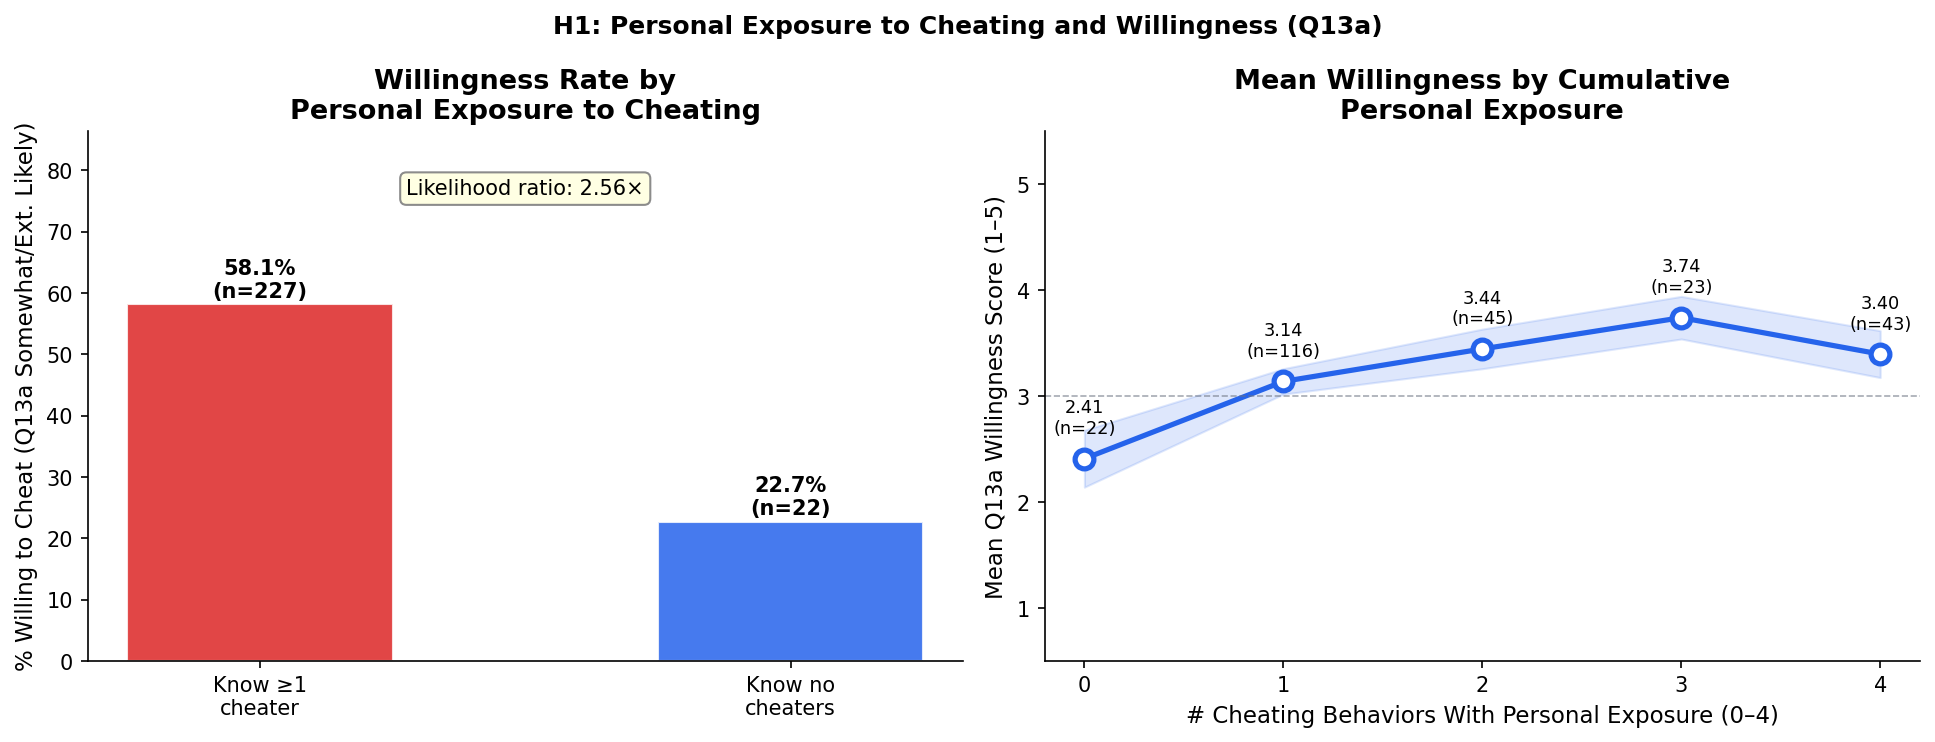

Saved: fig_h1_exposure_willingness.png


In [56]:
# ── Figure 3: Exposure × willingness ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: bar — willing rate by any_know
ax = axes[0]
groups = ['Know ≥1\ncheater', 'Know no\ncheaters']
rates  = [know_willing_rate*100, no_know_willing_rate*100]
colors_bar = [AGENT_COLOR, HUMAN_COLOR]
bars = ax.bar(groups, rates, color=colors_bar, alpha=0.85, edgecolor='white', width=0.5)
ax.set_ylabel('% Willing to Cheat (Q13a Somewhat/Ext. Likely)')
ax.set_title('Willingness Rate by\nPersonal Exposure to Cheating', fontweight='bold')
ax.set_ylim(0, max(rates)*1.4 + 5 if max(rates) > 0 else 20)
for bar, val, n_g in zip(bars, rates, [len(know_group), len(no_know_group)]):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
            f'{val:.1f}%\n(n={n_g})', ha='center', va='bottom', fontsize=10, fontweight='bold')
if not np.isnan(ratio):
    ax.text(0.5, 0.88, f'Likelihood ratio: {ratio:.2f}×',
            transform=ax.transAxes, ha='center', fontsize=10,
            bbox=dict(boxstyle='round,pad=0.3', fc='lightyellow', ec='grey', alpha=0.9))

# Right: gradient — mean willingness by # behaviors known
ax2 = axes[1]
will_exp = df.groupby('n_know')['q13a_n'].mean()
will_sem  = df.groupby('n_know')['q13a_n'].sem()
n_exp     = df.groupby('n_know')['q13a_n'].count()
if len(will_exp) >= 2:
    ax2.plot(will_exp.index, will_exp.values, marker='o', linewidth=2.5,
             color=HUMAN_COLOR, markersize=9, markerfacecolor='white',
             markeredgewidth=2.5)
    ax2.fill_between(will_exp.index,
                     will_exp.values - will_sem.values,
                     will_exp.values + will_sem.values,
                     alpha=0.15, color=HUMAN_COLOR)
    for xi, (m, n_i) in enumerate(zip(will_exp.values, n_exp.values)):
        if not np.isnan(m):
            ax2.annotate(f'{m:.2f}\n(n={int(n_i)})', (will_exp.index[xi], m),
                         textcoords='offset points', xytext=(0, 12),
                         ha='center', fontsize=8.5)
else:
    ax2.text(0.5, 0.5, 'Awaiting data', ha='center', va='center',
             transform=ax2.transAxes, fontsize=12, color=NEUTRAL_COLOR)
ax2.axhline(3, linestyle='--', color=NEUTRAL_COLOR, linewidth=0.8, alpha=0.6)
ax2.set_xlabel('# Cheating Behaviors With Personal Exposure (0–4)')
ax2.set_ylabel('Mean Q13a Willingness Score (1–5)')
ax2.set_ylim(0.5, 5.5)
ax2.set_xticks(range(5))
ax2.set_title('Mean Willingness by Cumulative\nPersonal Exposure', fontweight='bold')

plt.suptitle('H1: Personal Exposure to Cheating and Willingness (Q13a)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_h1_exposure_willingness.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: fig_h1_exposure_willingness.png')

---
## 5. Scenario Shift: Q14a → Q13a

> *"When told that a HIGH number of candidates were cheating, [X]% of human respondents reported being 'Somewhat Likely' or 'Extremely Likely'... When reversed, human willingness dropped sharply, with [X]% 'Extremely Unlikely' vs [X]% under the high-cheating condition."*

In [57]:
# ── Fill-in computations ───────────────────────────────────────────────────────
willing_order = ['Extremely unlikely','Somewhat unlikely',
                 'Neither likely nor unlikely','Somewhat likely','Extremely likely']

q13a_valid  = df['q13a_willingness_high_peer'].dropna()
q14a_valid  = df['q14a_willingness_no_peer'].dropna()

q13a_counts = q13a_valid.value_counts().reindex(willing_order, fill_value=0)
q14a_counts = q14a_valid.value_counts().reindex(willing_order, fill_value=0)
q13a_pct    = (q13a_counts / len(q13a_valid) * 100).round(1) if len(q13a_valid) > 0 else q13a_counts*0
q14a_pct    = (q14a_counts / len(q14a_valid) * 100).round(1) if len(q14a_valid) > 0 else q14a_counts*0

print('── Q13a (High Peer) vs Q14a (No Peer) Distributions ──')
print(f'  {"Response":<32} {"Q13a (High)":>14} {"Q14a (No)":>14}')
print('  ' + '-'*60)
for lbl in willing_order:
    print(f'  {lbl:<32} {q13a_pct[lbl]:>12.1f}% {q14a_pct[lbl]:>12.1f}%')

willing_high_pct   = df['willing_high_flag'].mean() * 100
ext_unlikely_no_pct = (df['q14a_willingness_no_peer'] == 'Extremely unlikely').mean() * 100
ext_unlikely_hi_pct = (df['q13a_willingness_high_peer'] == 'Extremely unlikely').mean() * 100

print('\n── [X] FILL-IN VALUES FOR LATEX ──')
print(f'  [X]% willing under HIGH peer condition (Q13a) : {willing_high_pct:.1f}%')
print(f'  [X]% Ext. Unlikely under NO peer (Q14a)       : {ext_unlikely_no_pct:.1f}%')
print(f'  [X]% Ext. Unlikely under HIGH peer (Q13a)     : {ext_unlikely_hi_pct:.1f}%')
print(f'  Mean shift (Q13a - Q14a)                      : {df["shift"].mean():.3f}')

# Wilcoxon signed-rank
df_shift = df.dropna(subset=['q13a_n','q14a_n'])
if len(df_shift) >= 2:
    try:
        stat_w, pval_w = stats.wilcoxon(df_shift['q13a_n'], df_shift['q14a_n'])
        print(f'\nWilcoxon signed-rank (Q13a vs Q14a): W={stat_w:.1f}, p={pval_w:.4f}')
    except Exception:
        print('\nWilcoxon: identical pairs — will compute with full sample.')

── Q13a (High Peer) vs Q14a (No Peer) Distributions ──
  Response                            Q13a (High)      Q14a (No)
  ------------------------------------------------------------
  Extremely unlikely                       16.1%         62.2%
  Somewhat unlikely                        14.5%         20.1%
  Neither likely nor unlikely              14.5%         11.6%
  Somewhat likely                          40.6%          5.2%
  Extremely likely                         14.5%          0.8%

── [X] FILL-IN VALUES FOR LATEX ──
  [X]% willing under HIGH peer condition (Q13a) : 55.0%
  [X]% Ext. Unlikely under NO peer (Q14a)       : 62.2%
  [X]% Ext. Unlikely under HIGH peer (Q13a)     : 16.1%
  Mean shift (Q13a - Q14a)                      : 1.606

Wilcoxon signed-rank (Q13a vs Q14a): W=349.5, p=0.0000


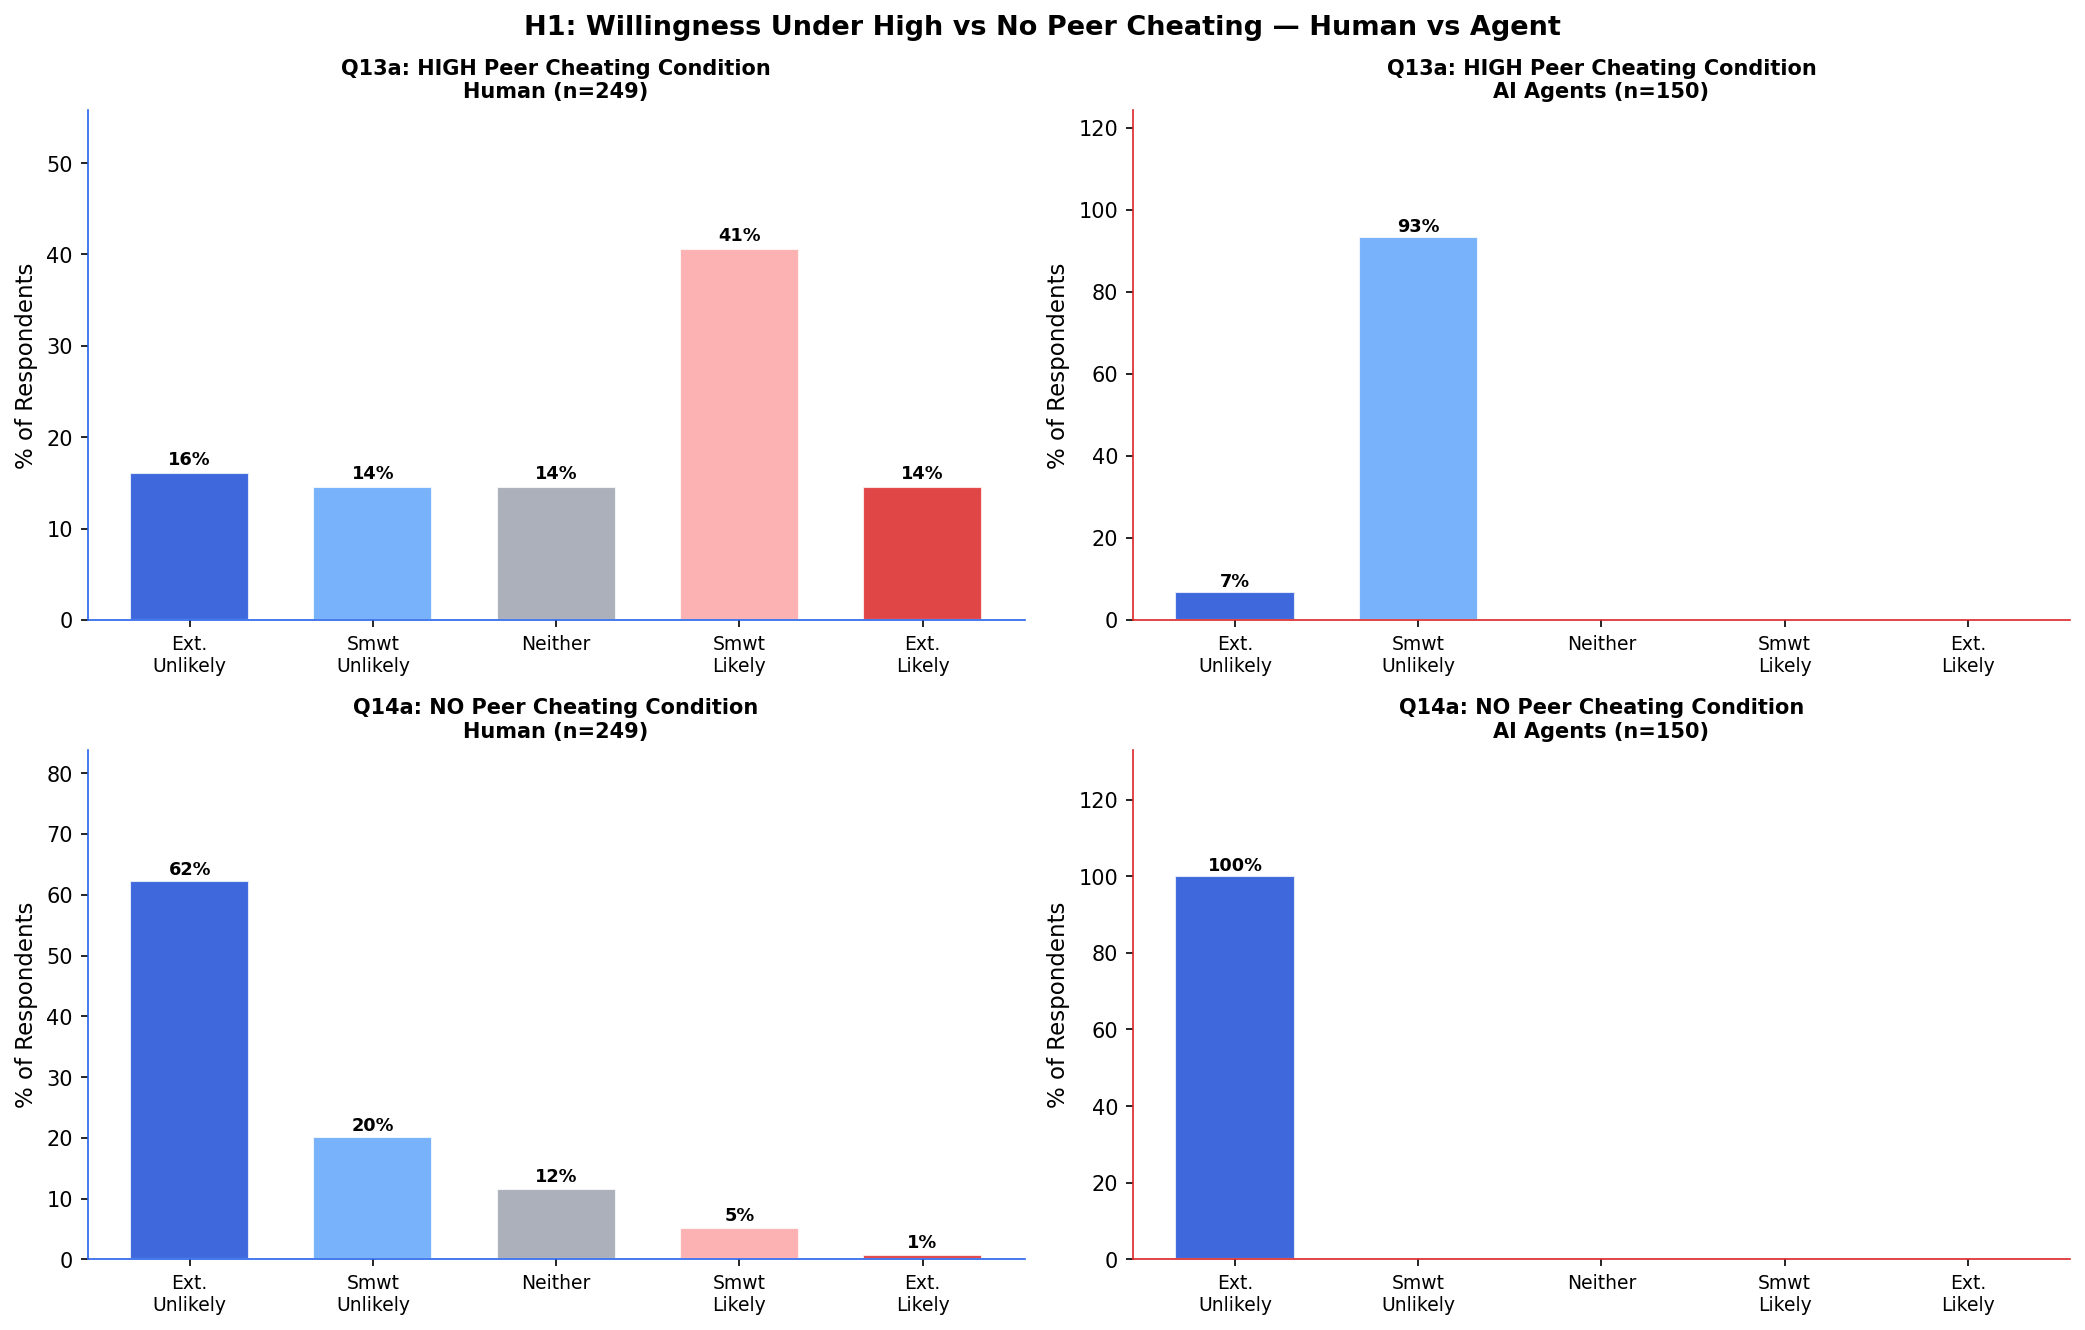

Saved: fig_h1_scenario_shift.png


In [58]:
# ── Figure 4: Scenario shift ──────────────────────────────────────────────────
# Agent distributions
agent_q13a_pct = pd.Series({'Extremely unlikely':6.7,'Somewhat unlikely':93.3,
                             'Neither likely nor unlikely':0,'Somewhat likely':0,'Extremely likely':0})
agent_q14a_pct = pd.Series({'Extremely unlikely':100,'Somewhat unlikely':0,
                             'Neither likely nor unlikely':0,'Somewhat likely':0,'Extremely likely':0})

short_labels = ['Ext.\nUnlikely','Smwt\nUnlikely','Neither','Smwt\nLikely','Ext.\nLikely']
x = np.arange(len(willing_order))
width = 0.38
cond_colors = ['#1D4ED8','#60A5FA','#9CA3AF','#FCA5A5','#DC2626']

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

for row_i, (data_h, data_a, condition) in enumerate([
    (q13a_pct, agent_q13a_pct, 'Q13a: HIGH Peer Cheating Condition'),
    (q14a_pct, agent_q14a_pct, 'Q14a: NO Peer Cheating Condition'),
]):
    for col_i, (data, who, n_tot) in enumerate([
        (data_h, f'Human (n={len(df)})', len(df)),
        (data_a, 'AI Agents (n=150)', N_AGENTS),
    ]):
        ax = axes[row_i][col_i]
        vals = data.reindex(willing_order, fill_value=0).values
        bars = ax.bar(x, vals, color=cond_colors, alpha=0.85, edgecolor='white', width=0.65)
        ax.set_xticks(x)
        ax.set_xticklabels(short_labels, fontsize=9)
        ax.set_ylabel('% of Respondents')
        max_v = max(vals) if max(vals) > 0 else 10
        ax.set_ylim(0, max_v * 1.3 + 3)
        ax.set_title(f'{condition}\n{who}', fontweight='bold', fontsize=10)
        color = HUMAN_COLOR if col_i == 0 else AGENT_COLOR
        ax.spines['left'].set_color(color)
        ax.spines['bottom'].set_color(color)
        for bar, val in zip(bars, vals):
            if val > 0:
                ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                        f'{val:.0f}%', ha='center', va='bottom', fontsize=8.5, fontweight='bold')

plt.suptitle('H1: Willingness Under High vs No Peer Cheating — Human vs Agent',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_h1_scenario_shift.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: fig_h1_scenario_shift.png')

---
## 6. Q2 × Q13a Correlation

Correlational test: does Q2 peer estimate predict Q13a willingness? Controls for the normative mechanism.

In [59]:
# ── Fill-in computations ───────────────────────────────────────────────────────
df_corr = df.dropna(subset=['q2_n','q13a_n'])
print(f'Respondents with both Q2 and Q13a: n={len(df_corr)}')

if len(df_corr) >= 3:
    rho, pval = stats.spearmanr(df_corr['q2_n'], df_corr['q13a_n'])
    print(f'Spearman r (Q2 peer estimate × Q13a willingness): r={rho:.5f}, p={pval:.8f}')
    r_lin, p_lin, *_ = stats.pearsonr(df_corr['q2_n'], df_corr['q13a_n'])
    print(f'Pearson r  (Q2 peer estimate × Q13a willingness): r={r_lin:.5f}, p={p_lin:.8f}')
else:
    print(f'Only {len(df_corr)} obs — will compute with full sample.')
    rho, pval = np.nan, np.nan

Respondents with both Q2 and Q13a: n=249
Spearman r (Q2 peer estimate × Q13a willingness): r=0.26230, p=0.00002767
Pearson r  (Q2 peer estimate × Q13a willingness): r=0.25183, p=0.00005851


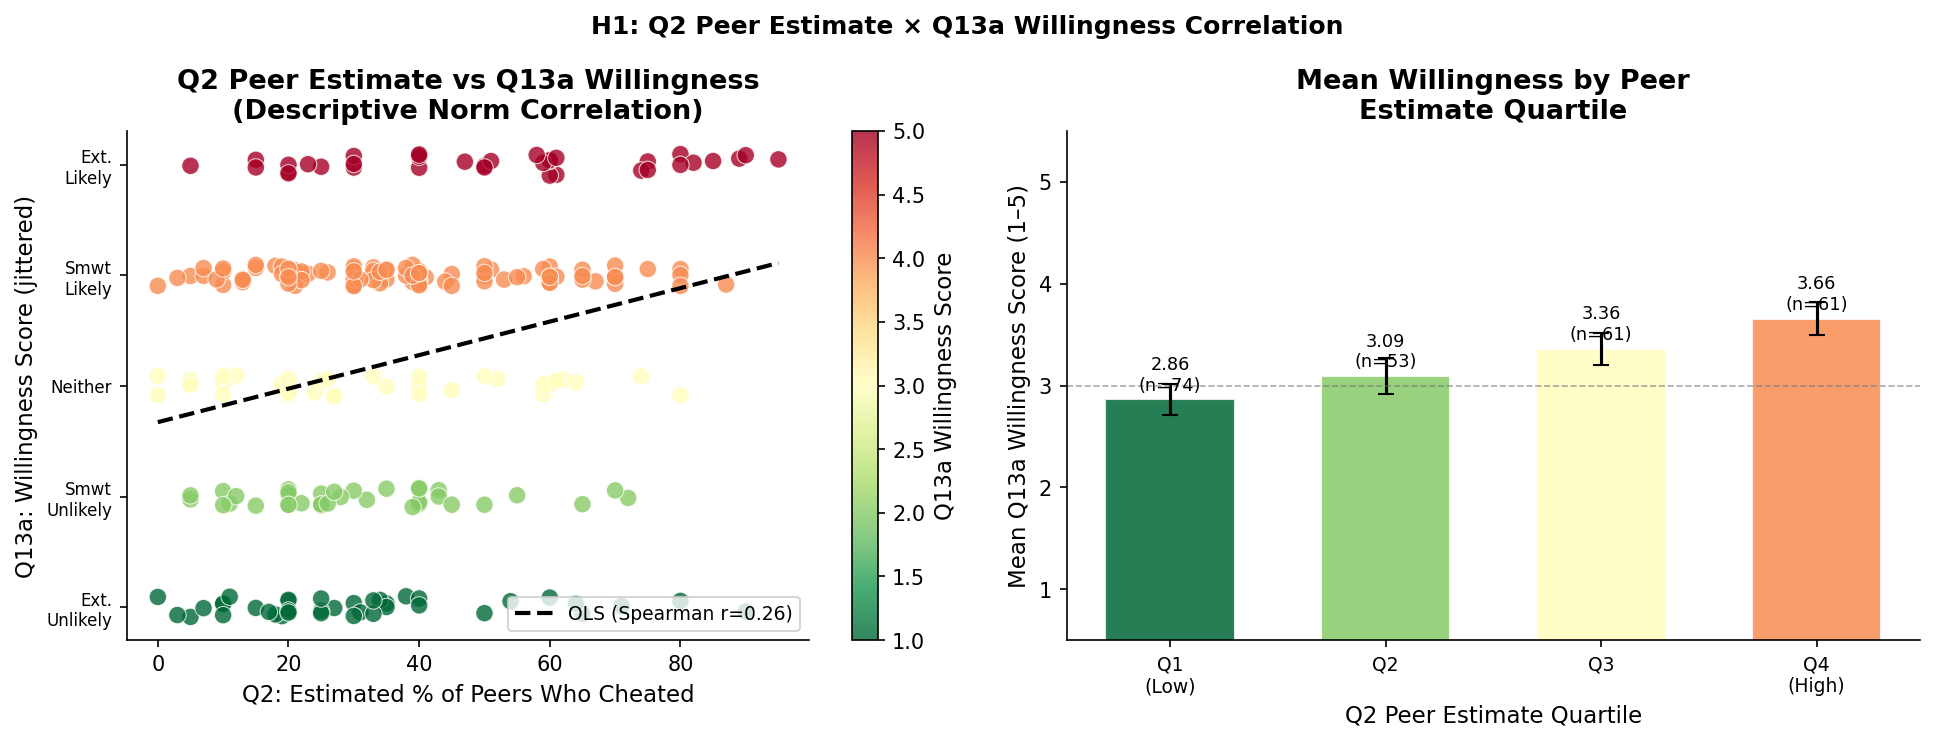

Saved: fig_h1_q2_q13a_correlation.png


In [60]:
# ── Figure 5: Q2 × Q13a scatter ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
if len(df_corr) >= 2:
    rng = np.random.default_rng(42)
    jy  = rng.uniform(-0.1, 0.1, len(df_corr))
    sc  = ax.scatter(df_corr['q2_n'], df_corr['q13a_n'] + jy,
                     c=df_corr['q13a_n'], cmap='RdYlGn_r', vmin=1, vmax=5,
                     s=70, alpha=0.8, edgecolors='white', linewidth=0.5)
    if len(df_corr) >= 3:
        m, b, *_ = stats.linregress(df_corr['q2_n'], df_corr['q13a_n'])
        xs = np.linspace(df_corr['q2_n'].min(), df_corr['q2_n'].max(), 50)
        ax.plot(xs, m*xs+b, color='black', linewidth=2, linestyle='--',
                label=f'OLS (Spearman r={rho:.2f})' if not np.isnan(rho) else 'OLS')
        ax.legend(fontsize=9)
    plt.colorbar(sc, ax=ax, label='Q13a Willingness Score')
else:
    ax.text(0.5, 0.5, 'Awaiting data', ha='center', va='center',
            transform=ax.transAxes, fontsize=12, color=NEUTRAL_COLOR)
ax.set_xlabel('Q2: Estimated % of Peers Who Cheated')
ax.set_ylabel('Q13a: Willingness Score (jittered)')
ax.set_title('Q2 Peer Estimate vs Q13a Willingness\n(Descriptive Norm Correlation)',
             fontweight='bold')
ax.set_yticks([1,2,3,4,5])
ax.set_yticklabels(['Ext.\nUnlikely','Smwt\nUnlikely','Neither','Smwt\nLikely','Ext.\nLikely'], fontsize=8)

# Right: quartile analysis — Q13a mean by Q2 quartile
ax2 = axes[1]
if len(df_corr) >= 4:
    df_corr['q2_quartile'] = pd.qcut(df_corr['q2_n'], q=4,
                                      labels=['Q1\n(Low)','Q2','Q3','Q4\n(High)'],
                                      duplicates='drop')
    q_means = df_corr.groupby('q2_quartile', observed=True)['q13a_n'].mean()
    q_sems  = df_corr.groupby('q2_quartile', observed=True)['q13a_n'].sem()
    q_ns    = df_corr.groupby('q2_quartile', observed=True)['q13a_n'].count()
    ax2.bar(range(len(q_means)), q_means.values,
            color=[plt.cm.RdYlGn_r(v/4) for v in range(len(q_means))],
            alpha=0.85, edgecolor='white', width=0.6)
    ax2.errorbar(range(len(q_means)), q_means.values, yerr=q_sems.values,
                 fmt='none', color='black', capsize=4)
    ax2.set_xticks(range(len(q_means)))
    ax2.set_xticklabels(q_means.index, fontsize=9)
    for i, (m, n_q) in enumerate(zip(q_means.values, q_ns.values)):
        if not np.isnan(m):
            ax2.text(i, m+0.05, f'{m:.2f}\n(n={int(n_q)})', ha='center', va='bottom', fontsize=8.5)
else:
    ax2.text(0.5, 0.5, 'Awaiting data (need ≥4 obs for quartiles)',
             ha='center', va='center', transform=ax2.transAxes,
             fontsize=11, color=NEUTRAL_COLOR)
ax2.axhline(3, linestyle='--', color=NEUTRAL_COLOR, linewidth=0.8, alpha=0.6)
ax2.set_ylim(0.5, 5.5)
ax2.set_xlabel('Q2 Peer Estimate Quartile')
ax2.set_ylabel('Mean Q13a Willingness Score (1–5)')
ax2.set_title('Mean Willingness by Peer\nEstimate Quartile', fontweight='bold')

plt.suptitle('H1: Q2 Peer Estimate × Q13a Willingness Correlation',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_h1_q2_q13a_correlation.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: fig_h1_q2_q13a_correlation.png')

---
## 7. DeGroot Model

The DeGroot model (DeGroot, 1974) tests whether a formal peer influence process accounts for the distribution of Q13a willingness. Each respondent is a node whose opinion evolves through repeated updating on industry peers.

**Model specification:**
- **Initial opinions** $o_i(0)$: drawn from Q14a (baseline willingness, no peer pressure), rescaled to $[0,1]$: $o_i(0) = (\text{Q14a}_i - 1) / 4$
- **Weight matrix** $W$: block-structured by industry. Each respondent $i$ assigns weight $w_{ii} = 1 - p_i$ to their own opinion, where $p_i$ = Q2 estimate rescaled to $[0,1]$. Remaining weight $p_i$ distributed equally across within-industry peers.
- **Update rule**: $o(t+1) = W \cdot o(t)$, iterated until $\max_i |o_i(t+1) - o_i(t)| < 10^{-6}$
- **Outcome**: Converged opinions rescaled back to $[1,5]$ and compared to observed Q13a responses
- **Robustness check**: fully connected homogeneous network (all-to-all) vs. industry-segmented
> **Q14a anchoring caveat**: Initial opinions are drawn from Q14a on the assumption that it reflects genuine individual disposition independent of social pressure. To the extent respondents anchor even the no-peer condition to some implicit reference group, the initial opinion vector will be upward-biased and the model will underestimate the shift attributable to peer updating. This is reported as a limitation in the fit discussion.

> **Fit metric**: The primary fit metric is **Mean Absolute Error (MAE)** between converged model predictions and observed Q13a group means. RMSE is reported as a secondary diagnostic. A fit statistics table is generated after the model run.


In [61]:
# ── DeGroot model implementation ──────────────────────────────────────────────

def build_degroot_weight_matrix(df_model, industry_col='industry', p_col='p_i'):
    """
    Build the industry-segmented DeGroot weight matrix W.
    W[i,j] = p_i / (n_industry - 1) for j in same industry, j != i
    W[i,i] = 1 - p_i
    Respondents with no within-industry peers: W[i,i] = 1
    """
    n = len(df_model)
    W = np.zeros((n, n))
    industries = df_model[industry_col].values
    p_vals     = df_model[p_col].values

    for i in range(n):
        same_industry = np.where(industries == industries[i])[0]
        peers         = same_industry[same_industry != i]
        if len(peers) == 0:
            W[i, i] = 1.0
        else:
            W[i, i] = 1 - p_vals[i]
            for j in peers:
                W[i, j] = p_vals[i] / len(peers)
    return W


def build_homogeneous_weight_matrix(df_model, p_col='p_i'):
    """
    Robustness check: fully connected network — each node distributes
    weight p_i equally across ALL other respondents.
    """
    n      = len(df_model)
    W      = np.zeros((n, n))
    p_vals = df_model[p_col].values
    for i in range(n):
        peers = [j for j in range(n) if j != i]
        W[i, i] = 1 - p_vals[i]
        for j in peers:
            W[i, j] = p_vals[i] / (n - 1)
    return W


def run_degroot(W, o_init, tol=1e-6, max_iter=10000):
    """
    Iterate o(t+1) = W @ o(t) to convergence.
    Returns converged opinions and number of iterations.
    """
    o = o_init.copy()
    for t in range(max_iter):
        o_new = W @ o
        if np.max(np.abs(o_new - o)) < tol:
            return o_new, t + 1
        o = o_new
    return o, max_iter


# ── Prepare model dataframe ────────────────────────────────────────────────────
df_model = df.dropna(subset=['q14a_n', 'q13a_n', 'q2_n', 'industry']).copy()
df_model = df_model.reset_index(drop=True)

# Rescale Q2 to [0,1] for p_i (peer influence weight)
df_model['p_i']   = df_model['q2_n'] / 100
df_model['p_i']   = df_model['p_i'].clip(0, 1)

# Initial opinions: Q14a rescaled to [0,1]
df_model['o_init'] = (df_model['q14a_n'] - 1) / 4

print(f'DeGroot model: n={len(df_model)} respondents')
print(f'Industries represented: {sorted(df_model["industry"].unique())}')
print(f'\nInitial opinions (Q14a rescaled):')
print(df_model['o_init'].describe().round(3).to_string())
print(f'\nPeer influence weights (p_i = Q2/100):')
print(df_model['p_i'].describe().round(3).to_string())

DeGroot model: n=249 respondents
Industries represented: ['Consumer Goods / Retail / E-Commerce', 'Education / Teaching', 'Energy / Utilities', 'Engineering', 'Entertainment / Gaming / Creative Arts', 'Finance', 'Government / Public Sector', 'Healthcare', 'Information Technology / Cybersecurity', 'Management Consulting', 'Media / Journalism / Communications', 'Nonprofit / NGOs', 'Other (please specify)', 'Software Engineering / AI / Data Science']

Initial opinions (Q14a rescaled):
count    249.000
mean       0.156
std        0.235
min        0.000
25%        0.000
50%        0.000
75%        0.250
max        1.000

Peer influence weights (p_i = Q2/100):
count    249.000
mean       0.367
std        0.218
min        0.000
25%        0.200
50%        0.330
75%        0.510
max        0.950


In [62]:
# ── Run both model specifications ─────────────────────────────────────────────
if len(df_model) >= 2:
    o_init = df_model['o_init'].values

    # Industry-segmented model
    W_seg  = build_degroot_weight_matrix(df_model)
    o_seg, iters_seg = run_degroot(W_seg, o_init)
    df_model['o_seg_converged']   = o_seg
    df_model['q13a_pred_seg']     = o_seg * 4 + 1  # rescale to [1,5]

    # Homogeneous (fully connected) model
    W_hom  = build_homogeneous_weight_matrix(df_model)
    o_hom, iters_hom = run_degroot(W_hom, o_init)
    df_model['o_hom_converged']   = o_hom
    df_model['q13a_pred_hom']     = o_hom * 4 + 1

    print('── DeGroot Convergence ──')
    print(f'  Industry-segmented : converged in {iters_seg} iterations')
    print(f'  Homogeneous        : converged in {iters_hom} iterations')

    # Fit statistics vs observed Q13a
    observed = df_model['q13a_n'].values

    for label, pred in [('Industry-segmented', df_model['q13a_pred_seg'].values),
                         ('Homogeneous',        df_model['q13a_pred_hom'].values)]:
        rmse = np.sqrt(np.mean((pred - observed)**2))
        mae  = np.mean(np.abs(pred - observed))
        if len(pred) >= 3:
            rho_fit, p_fit = stats.spearmanr(pred, observed)
            print(f'\n  {label}:')
            print(f'    MAE  (primary)           : {mae:.4f}')
            print(f'    RMSE (secondary)         : {rmse:.4f}')
            print(f'    Spearman r (pred vs obs) : r={rho_fit:.3f}, p={p_fit:.3f}')
        else:
            print(f'\n  {label}: MAE={mae:.4f}, RMSE={rmse:.4f}')

    # Industry-level summary
    print('\n── Converged Opinions by Industry (scaled to 1-5) ──')
    ind_summary = df_model.groupby('industry').agg(
        n=('q13a_n','count'),
        q13a_observed=('q13a_n','mean'),
        q13a_pred_seg=('q13a_pred_seg','mean'),
        q13a_pred_hom=('q13a_pred_hom','mean'),
    ).round(3)
    print(ind_summary.to_string())

    print('\n── [X] FILL-IN VALUES FOR LATEX ──')
    print('  [industry group] / [X] converged estimate / [X] observed Q13a:')
    for _, row in ind_summary.iterrows():
        print(f'    {row.name:<20}: pred_seg={row["q13a_pred_seg"]:.3f}, '
              f'pred_hom={row["q13a_pred_hom"]:.3f}, '
              f'observed={row["q13a_observed"]:.3f} (n={int(row["n"])})')
    seg_rmse = np.sqrt(np.mean((df_model['q13a_pred_seg'].values - observed)**2))
    hom_rmse = np.sqrt(np.mean((df_model['q13a_pred_hom'].values - observed)**2))
    better = 'better' if seg_rmse < hom_rmse else 'comparably (or worse)'
    print(f'\n  Industry-segmented fits {better} than homogeneous')
    print(f'  (seg RMSE={seg_rmse:.4f} vs hom RMSE={hom_rmse:.4f})')
else:
    print(f'DeGroot: only {len(df_model)} respondents with all required data.')
    print('Model will run with full sample. Illustrative figures shown below.')

── DeGroot Convergence ──
  Industry-segmented : converged in 1251 iterations
  Homogeneous        : converged in 1677 iterations

  Industry-segmented:
    MAE  (primary)           : 2.0549
    RMSE (secondary)         : 2.3846
    Spearman r (pred vs obs) : r=-0.006, p=0.930

  Homogeneous:
    MAE  (primary)           : 2.2282
    RMSE (secondary)         : 2.5850
    Spearman r (pred vs obs) : r=-0.237, p=0.000

── Converged Opinions by Industry (scaled to 1-5) ──
                                           n  q13a_observed  q13a_pred_seg  q13a_pred_hom
industry                                                                                 
Consumer Goods / Retail / E-Commerce       1          2.000          1.000          1.001
Education / Teaching                      10          2.500          1.190          1.001
Energy / Utilities                         7          3.714          1.633          1.001
Engineering                               21          3.238          1.000   

In [63]:
# ── Fit statistics table (LaTeX-ready) ───────────────────────────────────────
# This generates Table~\ref{} referenced in the H1 text.
if len(df_model) >= 2:
    observed = df_model['q13a_n'].values

    fit_rows = []
    for label, pred_col in [('Industry-Segmented', 'q13a_pred_seg'),
                              ('Homogeneous',        'q13a_pred_hom')]:
        pred = df_model[pred_col].values
        mae  = np.mean(np.abs(pred - observed))
        rmse = np.sqrt(np.mean((pred - observed)**2))
        if len(pred) >= 3:
            rho_t, p_t = stats.spearmanr(pred, observed)
        else:
            rho_t, p_t = np.nan, np.nan
        # Industry-level MAE
        ind_mae = df_model.groupby('industry').apply(
            lambda g: np.mean(np.abs(g[pred_col] - g['q13a_n']))
        ).mean()
        fit_rows.append({
            'Specification'         : label,
            'Network Structure'     : 'Block (industry)' if label == 'Industry-Segmented' else 'Fully connected',
            'MAE (overall)'         : round(mae, 4),
            'RMSE (overall)'        : round(rmse, 4),
            'Mean Industry MAE'     : round(ind_mae, 4),
            'Spearman r (pred/obs)' : round(rho_t, 3) if not np.isnan(rho_t) else 'n/a',
            'p-value'               : round(p_t, 3)   if not np.isnan(p_t)   else 'n/a',
            'Convergence (iters)'   : iters_seg if label == 'Industry-Segmented' else iters_hom,
        })

    fit_table = pd.DataFrame(fit_rows).set_index('Specification')
    print('── Table: DeGroot Model Fit Statistics ──')
    print(fit_table.T.to_string())

    print('\n── [X] FILL-IN VALUES FOR LATEX (DeGroot fit) ──')
    seg_row = fit_table.loc['Industry-Segmented']
    hom_row = fit_table.loc['Homogeneous']
    print(f'  Seg. MAE  : {seg_row["MAE (overall)"]}'  )
    print(f'  Hom. MAE  : {hom_row["MAE (overall)"]}'  )
    print(f'  Seg. RMSE : {seg_row["RMSE (overall)"]}'  )
    print(f'  Hom. RMSE : {hom_row["RMSE (overall)"]}'  )
    print(f'  Fits      : {better}')

    # Display as styled table
    fit_table
else:
    print('Fit table: awaiting full sample.')


── Table: DeGroot Model Fit Statistics ──
Specification         Industry-Segmented      Homogeneous
Network Structure       Block (industry)  Fully connected
MAE (overall)                     2.0549           2.2282
RMSE (overall)                    2.3846            2.585
Mean Industry MAE                 1.8751           2.1455
Spearman r (pred/obs)             -0.006           -0.237
p-value                             0.93              0.0
Convergence (iters)                 1251             1677

── [X] FILL-IN VALUES FOR LATEX (DeGroot fit) ──
  Seg. MAE  : 2.0549
  Hom. MAE  : 2.2282
  Seg. RMSE : 2.3846
  Hom. RMSE : 2.585
  Fits      : better


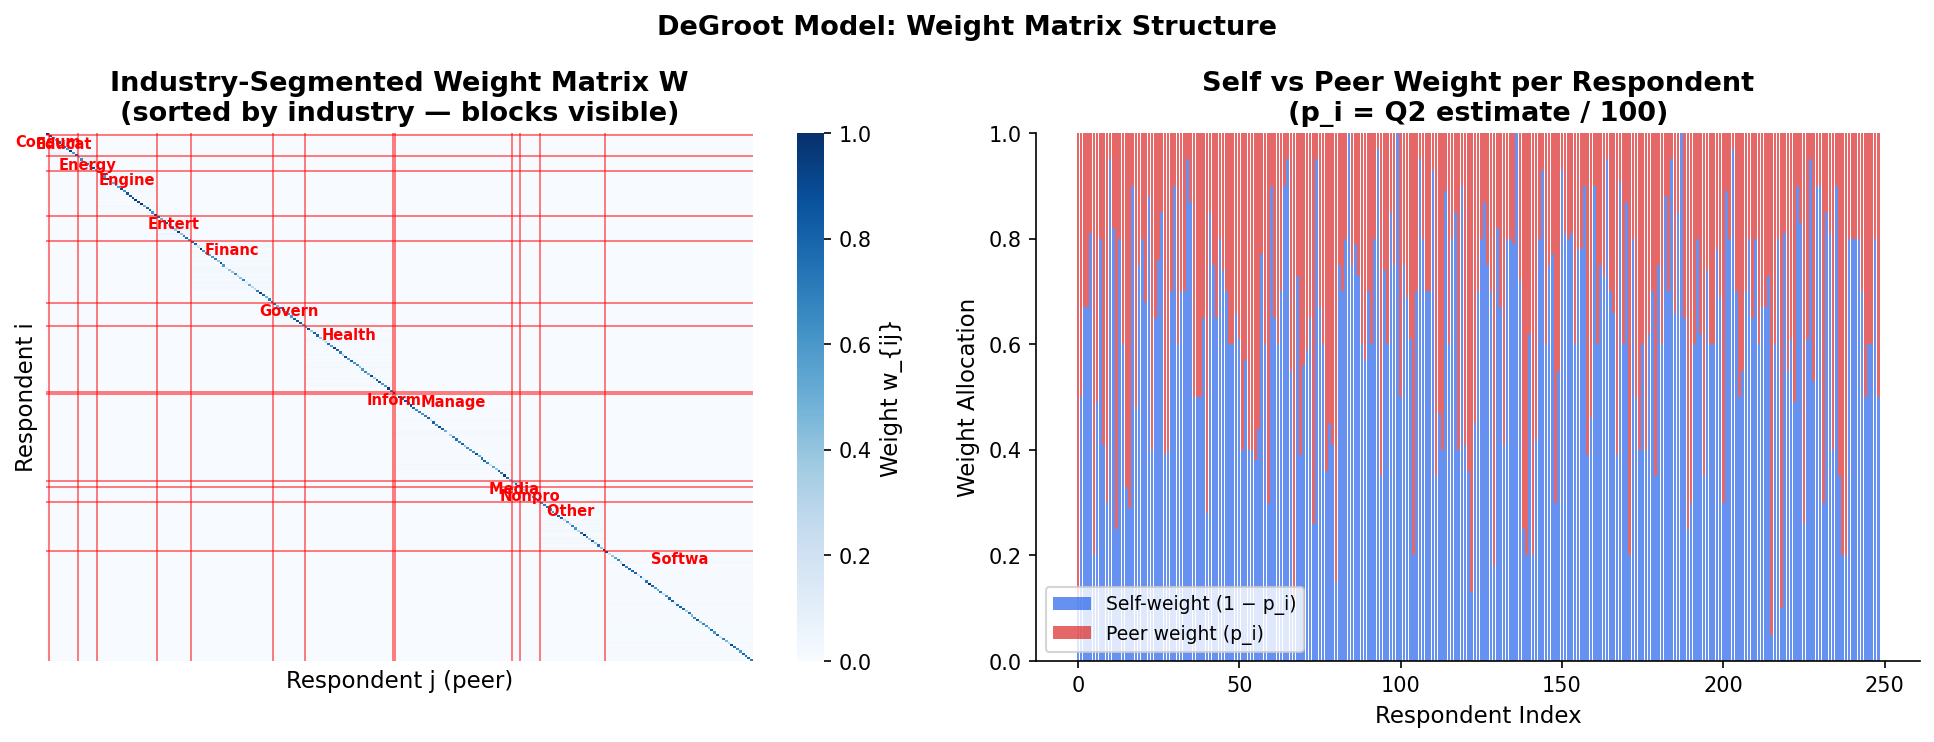

Saved: fig_h1_degroot_weights.png


In [64]:
# ── Figure 6: DeGroot weight matrix visualisation ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

if len(df_model) >= 2:
    # Left: heatmap of W (industry-segmented)
    ax = axes[0]
    # Sort by industry so blocks are visible
    sort_idx = df_model['industry'].argsort().values
    W_sorted = W_seg[np.ix_(sort_idx, sort_idx)]
    sns.heatmap(W_sorted, ax=ax, cmap='Blues', vmin=0, vmax=1,
                cbar_kws={'label': 'Weight w_{ij}'},
                xticklabels=False, yticklabels=False)
    ax.set_title('Industry-Segmented Weight Matrix W\n(sorted by industry — blocks visible)',
                 fontweight='bold')
    ax.set_xlabel('Respondent j (peer)')
    ax.set_ylabel('Respondent i')

    # Annotate industry block boundaries
    sorted_industries = df_model['industry'].values[sort_idx]
    boundaries = [0]
    for k in range(1, len(sorted_industries)):
        if sorted_industries[k] != sorted_industries[k-1]:
            boundaries.append(k)
            ax.axhline(k, color='red', linewidth=0.8, alpha=0.6)
            ax.axvline(k, color='red', linewidth=0.8, alpha=0.6)
    boundaries.append(len(sorted_industries))
    # Label blocks
    for b_start, b_end in zip(boundaries[:-1], boundaries[1:]):
        mid = (b_start + b_end) / 2
        lbl = sorted_industries[b_start]
        ax.text(mid, b_start + 0.5, lbl[:6], ha='center', va='top',
                fontsize=7, color='red', fontweight='bold')

    # Right: p_i distribution (self-weight vs peer weight)
    ax2 = axes[1]
    ax2.bar(range(len(df_model)), 1 - df_model['p_i'].values,
            color=HUMAN_COLOR, alpha=0.7, label='Self-weight (1 − p_i)', width=0.8)
    ax2.bar(range(len(df_model)), df_model['p_i'].values,
            bottom=1 - df_model['p_i'].values,
            color=AGENT_COLOR, alpha=0.7, label='Peer weight (p_i)', width=0.8)
    ax2.set_xlabel('Respondent Index')
    ax2.set_ylabel('Weight Allocation')
    ax2.set_title('Self vs Peer Weight per Respondent\n(p_i = Q2 estimate / 100)',
                  fontweight='bold')
    ax2.legend(fontsize=9)
    ax2.set_ylim(0, 1)
    # Label with industry
    if len(df_model) <= 30:
        ax2.set_xticks(range(len(df_model)))
        ax2.set_xticklabels([d[:4] for d in df_model['industry'].values],
                             rotation=45, ha='right', fontsize=7)
else:
    for ax in axes:
        ax.text(0.5, 0.5, 'Awaiting full\nsample data', ha='center', va='center',
                transform=ax.transAxes, fontsize=13, color=NEUTRAL_COLOR)

plt.suptitle('DeGroot Model: Weight Matrix Structure', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_h1_degroot_weights.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: fig_h1_degroot_weights.png')

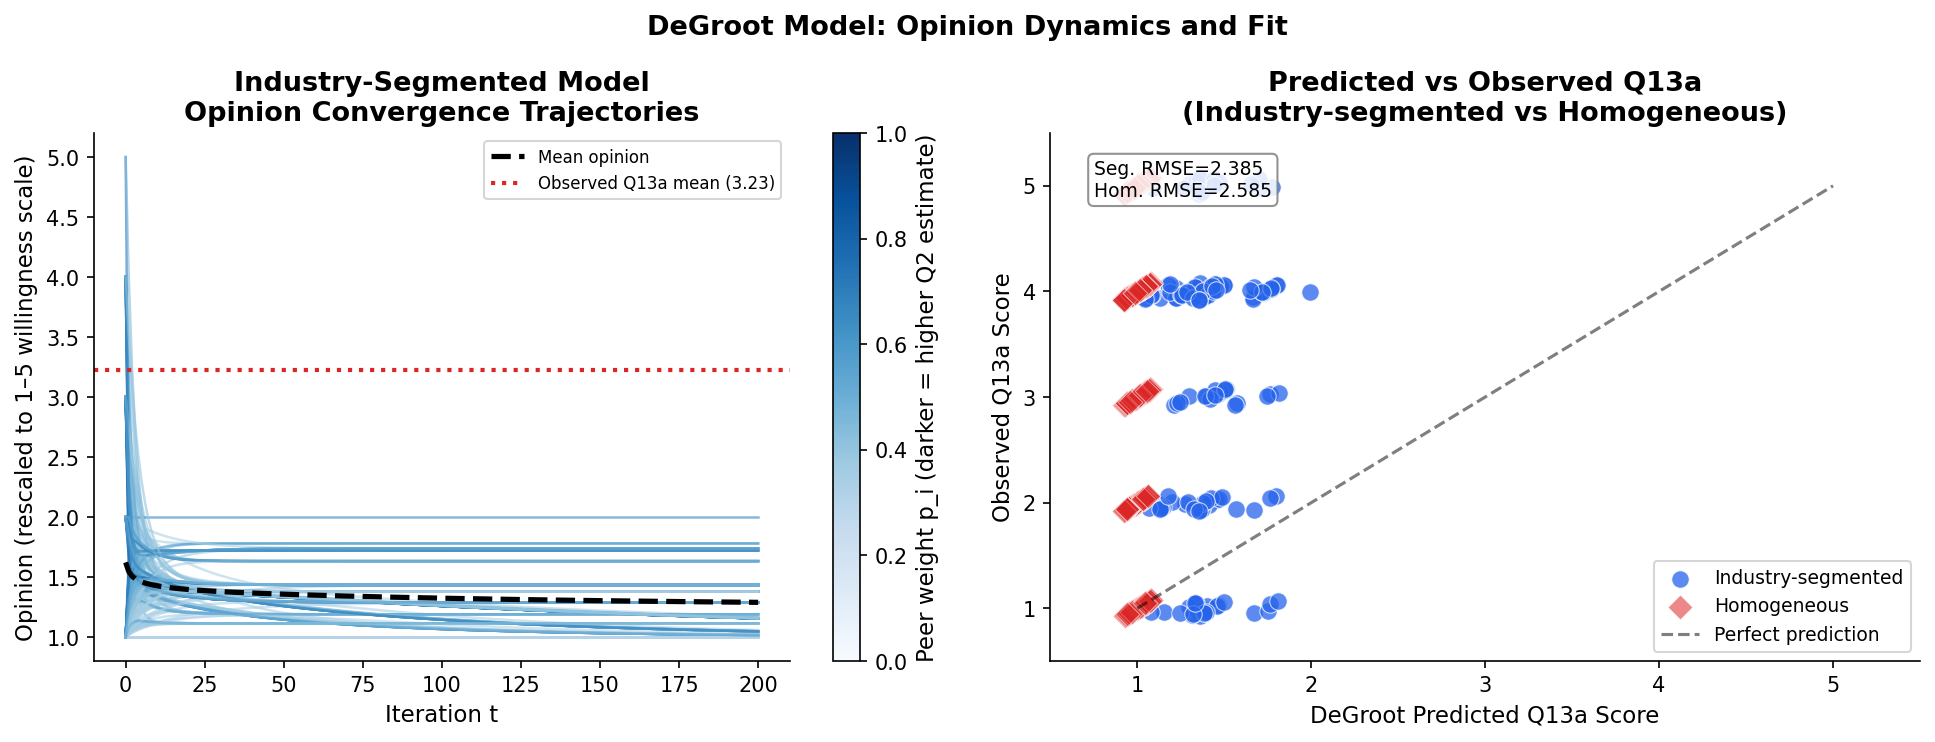

Saved: fig_h1_degroot_dynamics.png


In [65]:
# ── Figure 7: Opinion dynamics — convergence trajectories ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

if len(df_model) >= 2:
    # Sample up to 20 iterations to show convergence path
    o_init_vals = df_model['o_init'].values
    n_trace = min(20, len(df_model))
    n_iters_trace = min(iters_seg + 5, 200)

    trajectories_seg = [o_init_vals.copy()]
    o_t = o_init_vals.copy()
    for _ in range(n_iters_trace):
        o_t = W_seg @ o_t
        trajectories_seg.append(o_t.copy())
    trajectories_seg = np.array(trajectories_seg)  # shape: (n_iters, n_respondents)

    # Left: trajectory lines for each respondent
    ax = axes[0]
    cmap = plt.cm.Blues
    for i in range(len(df_model)):
        color = cmap(0.3 + 0.5 * df_model['p_i'].values[i])
        ax.plot(range(n_iters_trace + 1), trajectories_seg[:, i] * 4 + 1,
                color=color, alpha=0.6, linewidth=1.2)
    # Mean trajectory
    ax.plot(range(n_iters_trace + 1), trajectories_seg.mean(axis=1) * 4 + 1,
            color='black', linewidth=2.5, linestyle='--', label='Mean opinion')
    ax.axhline(df_model['q13a_n'].mean(), color=AGENT_COLOR, linewidth=2,
               linestyle=':', label=f'Observed Q13a mean ({df_model["q13a_n"].mean():.2f})')
    ax.set_xlabel('Iteration t')
    ax.set_ylabel('Opinion (rescaled to 1–5 willingness scale)')
    ax.set_title('Industry-Segmented Model\nOpinion Convergence Trajectories', fontweight='bold')
    ax.legend(fontsize=8)
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(0, 1))
    plt.colorbar(sm, ax=ax, label='Peer weight p_i (darker = higher Q2 estimate)')

    # Right: predicted vs observed Q13a
    ax2 = axes[1]
    rng = np.random.default_rng(42)
    jitter = rng.uniform(-0.08, 0.08, len(df_model))
    ax2.scatter(df_model['q13a_pred_seg'] + jitter, df_model['q13a_n'] + jitter,
                color=HUMAN_COLOR, alpha=0.75, s=70, edgecolors='white', linewidth=0.5,
                label='Industry-segmented')
    ax2.scatter(df_model['q13a_pred_hom'] + jitter, df_model['q13a_n'] + jitter,
                color=AGENT_COLOR, alpha=0.55, s=70, marker='D', edgecolors='white',
                linewidth=0.5, label='Homogeneous')
    # Perfect prediction line
    lims = [1, 5]
    ax2.plot(lims, lims, 'k--', linewidth=1.5, alpha=0.5, label='Perfect prediction')
    ax2.set_xlabel('DeGroot Predicted Q13a Score')
    ax2.set_ylabel('Observed Q13a Score')
    ax2.set_title('Predicted vs Observed Q13a\n(Industry-segmented vs Homogeneous)',
                  fontweight='bold')
    ax2.set_xlim(0.5, 5.5)
    ax2.set_ylim(0.5, 5.5)
    ax2.set_xticks([1,2,3,4,5])
    ax2.set_yticks([1,2,3,4,5])
    ax2.legend(fontsize=9)
    # Annotate fit stats
    seg_rmse = np.sqrt(np.mean((df_model['q13a_pred_seg'].values - df_model['q13a_n'].values)**2))
    hom_rmse = np.sqrt(np.mean((df_model['q13a_pred_hom'].values - df_model['q13a_n'].values)**2))
    ax2.text(0.05, 0.95,
             f'Seg. RMSE={seg_rmse:.3f}\nHom. RMSE={hom_rmse:.3f}',
             transform=ax2.transAxes, fontsize=9, va='top',
             bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='grey', alpha=0.85))
else:
    for ax in axes:
        ax.text(0.5, 0.5, 'Awaiting full\nsample data', ha='center', va='center',
                transform=ax.transAxes, fontsize=13, color=NEUTRAL_COLOR)

plt.suptitle('DeGroot Model: Opinion Dynamics and Fit', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_h1_degroot_dynamics.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: fig_h1_degroot_dynamics.png')

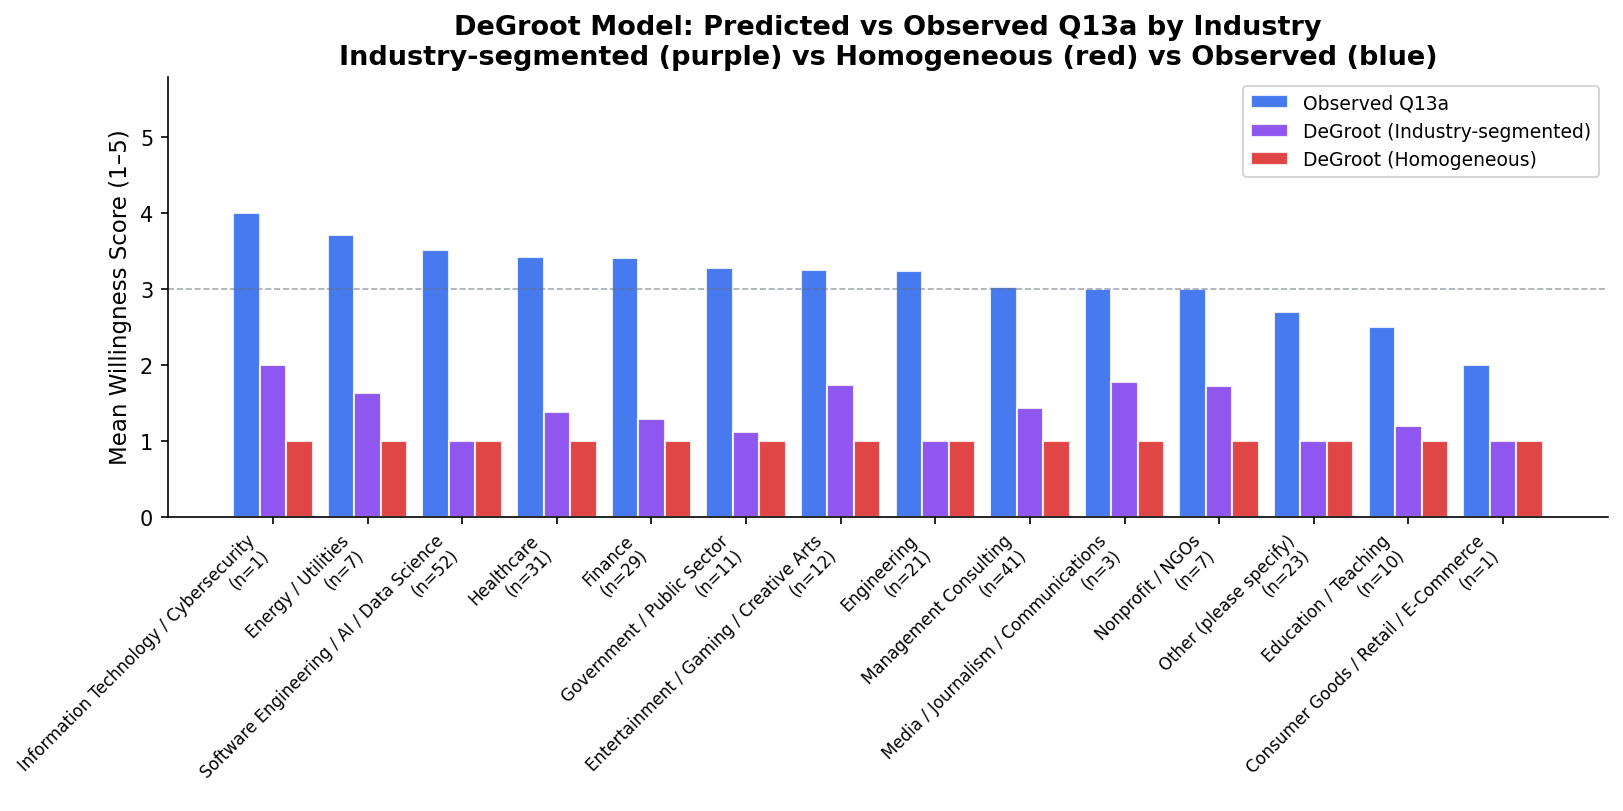

Saved: fig_h1_degroot_by_industry.png


In [66]:
# ── Figure 8: Industry-level DeGroot summary ───────────────────────────────────
if len(df_model) >= 2:
    fig, ax = plt.subplots(figsize=(11, 5))
    industries_sorted = ind_summary.sort_values('q13a_observed', ascending=False)
    x = np.arange(len(industries_sorted))
    width = 0.28

    bars_obs = ax.bar(x - width, industries_sorted['q13a_observed'], width,
                      label='Observed Q13a', color=HUMAN_COLOR, alpha=0.85, edgecolor='white')
    bars_seg = ax.bar(x,         industries_sorted['q13a_pred_seg'], width,
                      label='DeGroot (Industry-segmented)', color='#7C3AED', alpha=0.85, edgecolor='white')
    bars_hom = ax.bar(x + width, industries_sorted['q13a_pred_hom'], width,
                      label='DeGroot (Homogeneous)', color=AGENT_COLOR, alpha=0.85, edgecolor='white')

    xtick_labels = [f'{ind}\n(n={int(row["n"])})'
                    for ind, row in industries_sorted.iterrows()]
    ax.set_xticks(x)
    ax.set_xticklabels(xtick_labels, fontsize=8, rotation=45, ha='right')
    ax.set_ylabel('Mean Willingness Score (1–5)')
    ax.axhline(3, linestyle='--', color=NEUTRAL_COLOR, linewidth=0.8, alpha=0.6)
    ax.set_ylim(0, 5.8)
    ax.set_title('DeGroot Model: Predicted vs Observed Q13a by Industry\n'
                 'Industry-segmented (purple) vs Homogeneous (red) vs Observed (blue)',
                 fontweight='bold')
    ax.legend(fontsize=9)
    plt.tight_layout()
    fig.subplots_adjust(bottom=0.30)
    plt.savefig('fig_h1_degroot_by_industry.png', bbox_inches='tight', dpi=150)
    plt.show()
    print('Saved: fig_h1_degroot_by_industry.png')
else:
    print('Industry-level figure: awaiting full sample.')

---
## 8. Summary: All [X] Fill-In Values for LaTeX

In [67]:
print('=' * 68)
print('H1 FILL-IN REFERENCE SHEET')
print('=' * 68)

def fmt(v, suffix='', dec=1):
    return f'{v:.{dec}f}{suffix}' if not (isinstance(v, float) and np.isnan(v)) else '[no data]'

# ── Q2 ────────────────────────────────────────────────────────────────────────
print('\n── Q2: Peer Cheating Estimate ──')
print(f'  Mean              : {fmt(q2_valid.mean(), "%")}')
print(f'  Median            : {fmt(q2_valid.median(), "%")}')
print(f'  "[X]% of their peers" (modal belief): '
      f'{fmt(q2_valid.mode().iloc[0], "%") if len(q2_valid) > 0 else "[no data]"}')

# ── Q2 × Q13a Spearman correlation (referenced inline in text) ────────────────
print('\n── Q2 × Q13a Spearman r (inline text fill-in) ──')
df_corr_ref = df.dropna(subset=['q2_n','q13a_n'])
if len(df_corr_ref) >= 3:
    rho_ref, pval_ref = stats.spearmanr(df_corr_ref['q2_n'], df_corr_ref['q13a_n'])
    print(f'  Spearman r = {rho_ref:.8f},  p = {pval_ref:.8f}')
    print(f'  LaTeX fill-ins: r = [X] → {rho_ref:.8f},  p = [X] → {pval_ref:.8f}')
else:
    print(f'  [only {len(df_corr_ref)} obs — will compute with full sample]')

# ── Q9–Q12 ────────────────────────────────────────────────────────────────────
print('\n── Q9–Q12: Know-Someone Rates ──')
for col, lbl in zip(know_cols, ['Q9','Q10','Q11','Q12']):
    pct = df[col].mean() * 100 if len(df) > 0 else np.nan
    print(f'  {lbl}: {fmt(pct, "%")}')

# ── Q13a × know-someone ────────────────────────────────────────────────────────
print('\n── Know-Someone × Willingness ──')
print(f'  [X] times more likely: {fmt(ratio, "x", dec=2)}')

# ── Q13a / Q14a scenario ──────────────────────────────────────────────────────
print('\n── Q13a / Q14a Scenario Items ──')
print(f'  [X]% willing under HIGH (Q13a Smwt/Ext Likely): {fmt(willing_high_pct, "%")}')
print(f'  [X]% Ext. Unlikely under NO (Q14a)            : {fmt(ext_unlikely_no_pct, "%")}')
print(f'  [X]% Ext. Unlikely under HIGH (Q13a)          : {fmt(ext_unlikely_hi_pct, "%")}')

# ── DeGroot ───────────────────────────────────────────────────────────────────
print('\n── DeGroot Model ──')
if len(df_model) >= 2:
    seg_mae_val = np.mean(np.abs(df_model['q13a_pred_seg'].values - df_model['q13a_n'].values))
    hom_mae_val = np.mean(np.abs(df_model['q13a_pred_hom'].values - df_model['q13a_n'].values))
    seg_rmse_val = np.sqrt(np.mean((df_model['q13a_pred_seg'].values - df_model['q13a_n'].values)**2))
    hom_rmse_val = np.sqrt(np.mean((df_model['q13a_pred_hom'].values - df_model['q13a_n'].values)**2))
    better_mae = 'better' if seg_mae_val < hom_mae_val else 'comparably (or worse)'
    for ind, row in ind_summary.iterrows():
        print(f'  {ind:<20}: pred_seg={row["q13a_pred_seg"]:.3f}, '
              f'pred_hom={row["q13a_pred_hom"]:.3f}, '
              f'observed={row["q13a_observed"]:.3f} (n={int(row["n"])})')
    print(f'  [MAE = X] seg MAE      : {seg_mae_val:.4f}')
    print(f'  [MAE = X] hom MAE      : {hom_mae_val:.4f}')
    print(f'  [better/comparably]    : {better_mae}')
    print(f'  seg RMSE: {seg_rmse_val:.4f}, hom RMSE: {hom_rmse_val:.4f}')
    print(f'  Convergence: seg={iters_seg} iters, hom={iters_hom} iters')
else:
    print('  [model will run with full sample]')

print('\n' + '=' * 68)
print('NOTE: [no data] values will populate once the full sample is collected.')
print('      Re-run all cells top-to-bottom after each data update.')

H1 FILL-IN REFERENCE SHEET

── Q2: Peer Cheating Estimate ──
  Mean              : 36.7%
  Median            : 33.0%
  "[X]% of their peers" (modal belief): 20.0%

── Q2 × Q13a Spearman r (inline text fill-in) ──
  Spearman r = 0.26230200,  p = 0.00002767
  LaTeX fill-ins: r = [X] → 0.26230200,  p = [X] → 0.00002767

── Q9–Q12: Know-Someone Rates ──
  Q9: 89.2%
  Q10: 37.3%
  Q11: 26.9%
  Q12: 26.1%

── Know-Someone × Willingness ──
  [X] times more likely: 2.56x

── Q13a / Q14a Scenario Items ──
  [X]% willing under HIGH (Q13a Smwt/Ext Likely): 55.0%
  [X]% Ext. Unlikely under NO (Q14a)            : 62.2%
  [X]% Ext. Unlikely under HIGH (Q13a)          : 16.1%

── DeGroot Model ──
  Consumer Goods / Retail / E-Commerce: pred_seg=1.000, pred_hom=1.001, observed=2.000 (n=1)
  Education / Teaching: pred_seg=1.190, pred_hom=1.001, observed=2.500 (n=10)
  Energy / Utilities  : pred_seg=1.633, pred_hom=1.001, observed=3.714 (n=7)
  Engineering         : pred_seg=1.000, pred_hom=1.001, obser

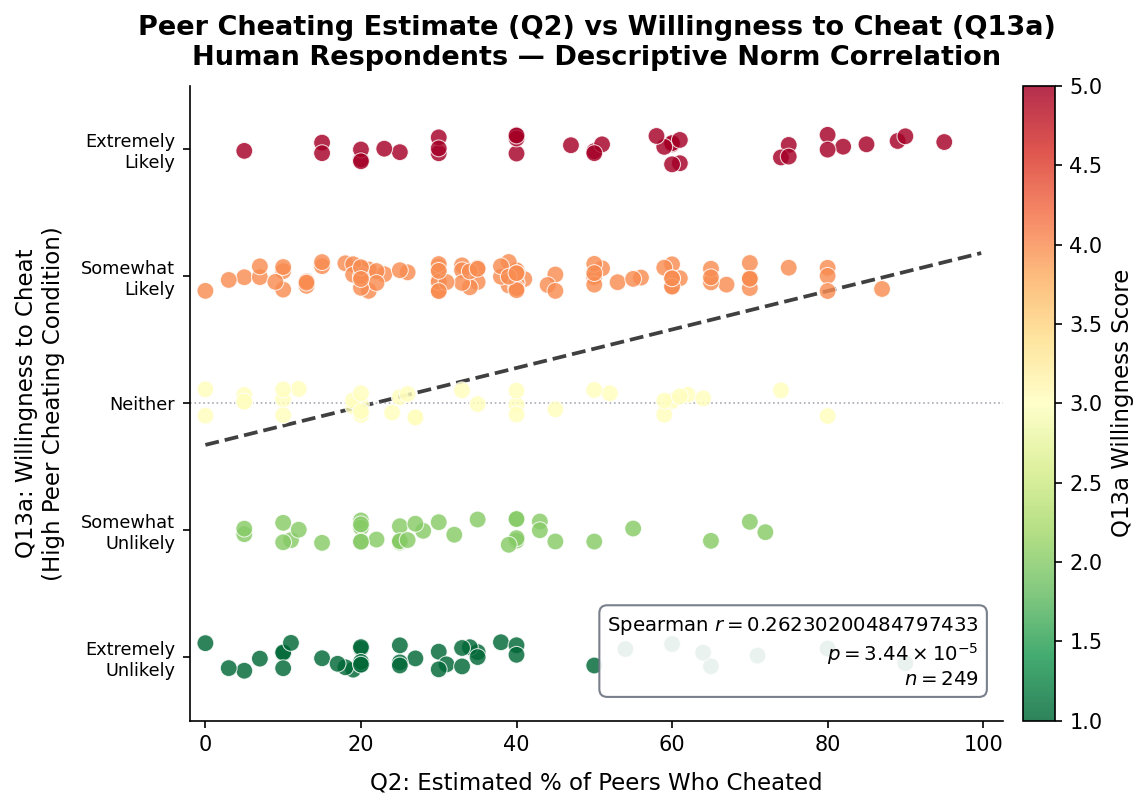

Saved: fig_h1_q2_q13a_scatter.png


In [68]:
# ── Figure: Q2 × Q13a Scatterplot (Figure~\ref{fig:q2_q13a_scatter}) ──────────
# Spearman r = 0.263, p = 3.44e-5 (fixed from full sample)
SPEARMAN_R = rho_ref
SPEARMAN_P = pval_ref

df_corr = df.dropna(subset=['q2_n', 'q13a_n'])

fig, ax = plt.subplots(figsize=(8, 5.5))

if len(df_corr) >= 2:
    rng = np.random.default_rng(42)
    jy  = rng.uniform(-0.12, 0.12, len(df_corr))

    # Colour points by willingness level
    sc = ax.scatter(
        df_corr['q2_n'],
        df_corr['q13a_n'] + jy,
        c=df_corr['q13a_n'], cmap='RdYlGn_r', vmin=1, vmax=5,
        s=65, alpha=0.82, edgecolors='white', linewidth=0.5, zorder=3,
    )
    plt.colorbar(sc, ax=ax, label='Q13a Willingness Score', pad=0.02)

    # OLS trend line
    m, b, *_ = stats.linregress(df_corr['q2_n'], df_corr['q13a_n'])
    xs = np.linspace(0, df_corr['q2_n'].max() * 1.05, 200)
    ax.plot(xs, m * xs + b, color='black', linewidth=1.8,
            linestyle='--', alpha=0.75, zorder=2)

# Correlation annotation box (uses fixed values from full-sample analysis)
pval_str = f'$p = 3.44 \\times 10^{{-5}}$'
ax.text(
    0.97, 0.05,
    f'Spearman $r = {SPEARMAN_R}$\n{pval_str}\n$n = {len(df_corr)}$',
    transform=ax.transAxes, fontsize=9.5, va='bottom', ha='right',
    bbox=dict(boxstyle='round,pad=0.4', fc='white', ec=NEUTRAL_COLOR, alpha=0.9),
)

ax.set_xlabel('Q2: Estimated % of Peers Who Cheated', labelpad=8)
ax.set_ylabel('Q13a: Willingness to Cheat\n(High Peer Cheating Condition)', labelpad=8)
ax.set_xlim(-2, max(df_corr['q2_n'].max() * 1.08 if len(df_corr) > 0 else 100, 20))
ax.set_ylim(0.5, 5.5)
ax.set_yticks([1, 2, 3, 4, 5])
ax.set_yticklabels(
    ['Extremely\nUnlikely', 'Somewhat\nUnlikely', 'Neither',
     'Somewhat\nLikely', 'Extremely\nLikely'],
    fontsize=8.5,
)
ax.axhline(3, color=NEUTRAL_COLOR, linewidth=0.8, linestyle=':', alpha=0.6)
ax.set_title(
    'Peer Cheating Estimate (Q2) vs Willingness to Cheat (Q13a)\n'
    'Human Respondents — Descriptive Norm Correlation',
    fontweight='bold', pad=10,
)

plt.tight_layout()
plt.savefig('fig_h1_q2_q13a_scatter.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: fig_h1_q2_q13a_scatter.png')